# Pattern Analysis: Replica & SLO (Response Time)

Pattern analysis replica count and SLO (response time)
- **Q-Learning (QL)**
- **Q-Learning Fuzzy (QF)**
- **HPA (Baseline)**


## 1. Setup & Konfigurasi Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

DATA_DIR = 'data-testing/19-02-2026'
SLO_THRESHOLD = 1000  # ms

# ─────────────────────────────────────────────────────────────────
# Dataset arrays — edit file names here to add/remove runs
# ─────────────────────────────────────────────────────────────────
DATASETS = {
    'Q-Learning': [
        f'{DATA_DIR}/q-learning/test_Q-LEARNING_20260221_192803.csv',  # Run 1
        # f'{DATA_DIR}/q-learning/test_Q-LEARNING_20260221_200210.csv',  # Run 2 (must)
        f'{DATA_DIR}/q-learning/test_Q-LEARNING_20260221_203652.csv',  # Run 3
        f'{DATA_DIR}/q-learning/test_Q-LEARNING_20260221_211202.csv',  # Run 4
        f'{DATA_DIR}/q-learning/test_Q-LEARNING_20260221_221533.csv',  # Run 5
        f'{DATA_DIR}/q-learning/test_Q-LEARNING_20260221_225653.csv',  # Run 6
    ],
    'Q-Learning Fuzzy': [
        f'{DATA_DIR}/q-learning-fuzzy/test_Q-LEARNING-FUZZY_20260221_192707.csv',  # Run 1
        f'{DATA_DIR}/q-learning-fuzzy/test_Q-LEARNING-FUZZY_20260221_200234.csv',  # Run 2
        f'{DATA_DIR}/q-learning-fuzzy/test_Q-LEARNING-FUZZY_20260221_203547.csv',  # Run 3
        # f'{DATA_DIR}/q-learning-fuzzy/test_Q-LEARNING-FUZZY_20260221_211239.csv',  # Run 4 (must)
        f'{DATA_DIR}/q-learning-fuzzy/test_Q-LEARNING-FUZZY_20260221_221443.csv',  # Run 5
        f'{DATA_DIR}/q-learning-fuzzy/test_Q-LEARNING-FUZZY_20260221_225713.csv',  # Run 6
    ],
    'HPA': [
        f'{DATA_DIR}/hpa/metrics_20260221_233530.csv',  # Run 1
        f'{DATA_DIR}/hpa/metrics_20260221_233600.csv',  # Run 2
        f'{DATA_DIR}/hpa/metrics_20260222_001647.csv',  # Run 3
        # f'{DATA_DIR}/hpa/metrics_20260222_001717.csv',  # Run 4
        f'{DATA_DIR}/hpa/metrics_20260222_005045.csv',  # Run 5
        f'{DATA_DIR}/hpa/metrics_20260222_005111.csv',  # Run 6 (must)
    ],
}

# Color palette per method (base color → 6 shades from light to dark)
METHOD_COLORS = {
    'Q-Learning':       plt.cm.Greens(np.linspace(0.35, 0.9, 6)),
    'Q-Learning Fuzzy': plt.cm.Blues(np.linspace(0.35, 0.9, 6)),
    'HPA':              plt.cm.Oranges(np.linspace(0.35, 0.9, 6)),
}

# Single representative color per method (for cross-method plots)
METHOD_BASE_COLOR = {
    'Q-Learning':       '#26A69A',
    'Q-Learning Fuzzy': '#5C6BC0',
    'HPA':              '#FF7043',
}

print('Dataset configuration:')
for method, files in DATASETS.items():
    print(f'  {method}: {len(files)} files')

Dataset configuration:
  Q-Learning: 5 files
  Q-Learning Fuzzy: 5 files
  HPA: 5 files


## 2. Load Data

In [2]:
# Load semua dataset ke dalam dict: method -> list of DataFrames
ALL_DATA = {}

for method, file_list in DATASETS.items():
    dfs = []
    for i, filepath in enumerate(file_list):
        df = pd.read_csv(filepath, parse_dates=['timestamp'])
        df['elapsed_s'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
        df['elapsed_min'] = df['elapsed_s'] / 60.0
        df['run'] = i + 1
        dfs.append(df)
    ALL_DATA[method] = dfs
    print(f'{method}:')
    for i, df in enumerate(dfs):
        rt_valid = df['response_time_ms'].dropna()
        rt_valid = rt_valid[rt_valid > 0]
        duration = df['elapsed_s'].iloc[-1]
        print(f'  Run {i+1}: {len(df)} rows | {duration:.0f}s | '
              f'replica: {df["replica_state"].min()}-{df["replica_state"].max()} | '
              f'RT mean: {rt_valid.mean():.0f}ms' if len(rt_valid) > 0 else f'  Run {i+1}: {len(df)} rows | {duration:.0f}s | no RT data')
    print()

Q-Learning:
  Run 1: 121 rows | 1862s | replica: 1-1 | RT mean: 3282ms
  Run 2: 122 rows | 1862s | replica: 1-1 | RT mean: 3199ms
  Run 3: 121 rows | 1845s | replica: 1-1 | RT mean: 3215ms
  Run 4: 121 rows | 1845s | replica: 1-1 | RT mean: 3216ms
  Run 5: 122 rows | 1858s | replica: 1-1 | RT mean: 3201ms

Q-Learning Fuzzy:
  Run 1: 121 rows | 1846s | replica: 1-10 | RT mean: 270ms
  Run 2: 122 rows | 1857s | replica: 1-9 | RT mean: 374ms
  Run 3: 121 rows | 1847s | replica: 1-9 | RT mean: 485ms
  Run 4: 122 rows | 1860s | replica: 1-9 | RT mean: 506ms
  Run 5: 122 rows | 1858s | replica: 1-10 | RT mean: 306ms

HPA:
  Run 1: 123 rows | 1988s | replica: 1-10 | RT mean: 106ms
  Run 2: 123 rows | 1989s | replica: 1-10 | RT mean: 106ms
  Run 3: 122 rows | 1858s | replica: 1-10 | RT mean: 115ms
  Run 4: 122 rows | 1858s | replica: 1-10 | RT mean: 226ms
  Run 5: 122 rows | 1858s | replica: 1-10 | RT mean: 218ms



## 3. Pattern Replica Count 


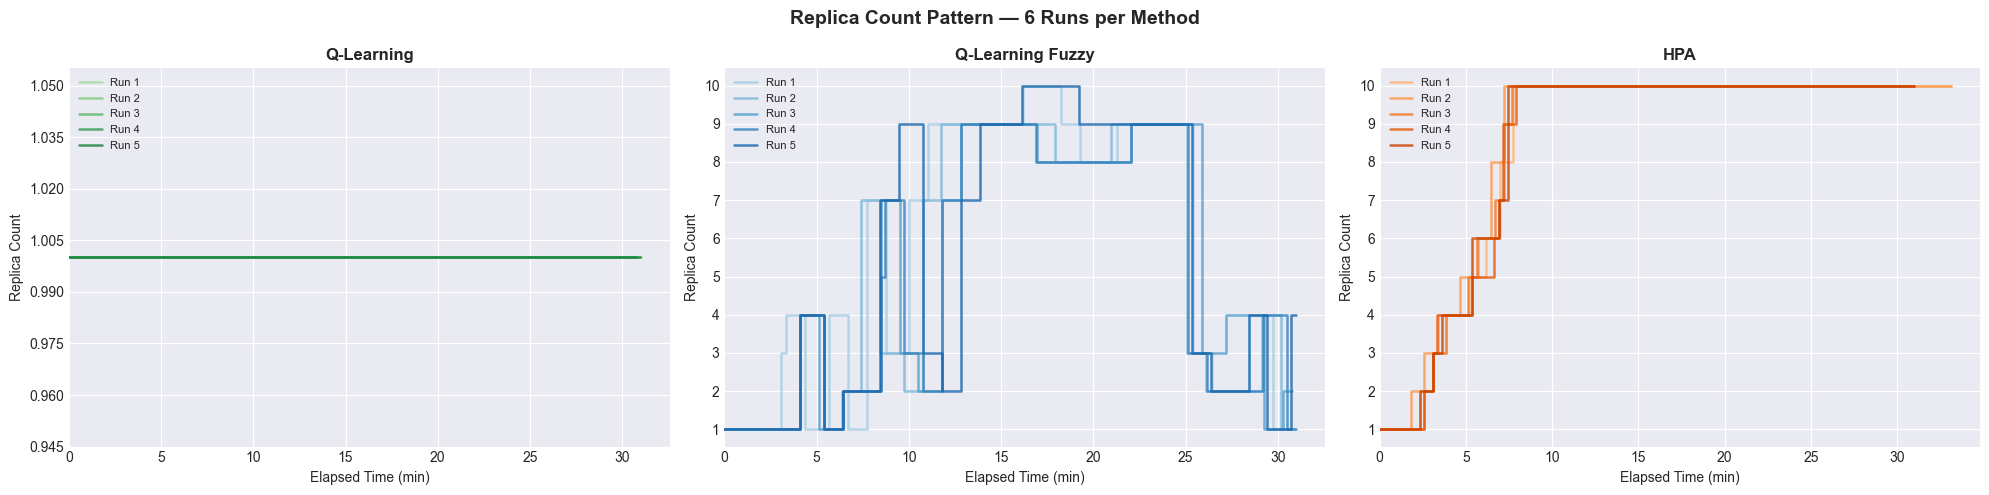

In [3]:
methods = list(DATASETS.keys())

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle('Replica Count Pattern — 6 Runs per Method', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]

    for i, df in enumerate(dfs):
        ax.step(df['elapsed_min'], df['replica_state'], where='post',
                linewidth=1.8, alpha=0.8, color=colors[i], label=f'Run {i+1}')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (min)')
    ax.set_ylabel('Replica Count')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 4. Pattern Replica Count — Mean ± Std Band

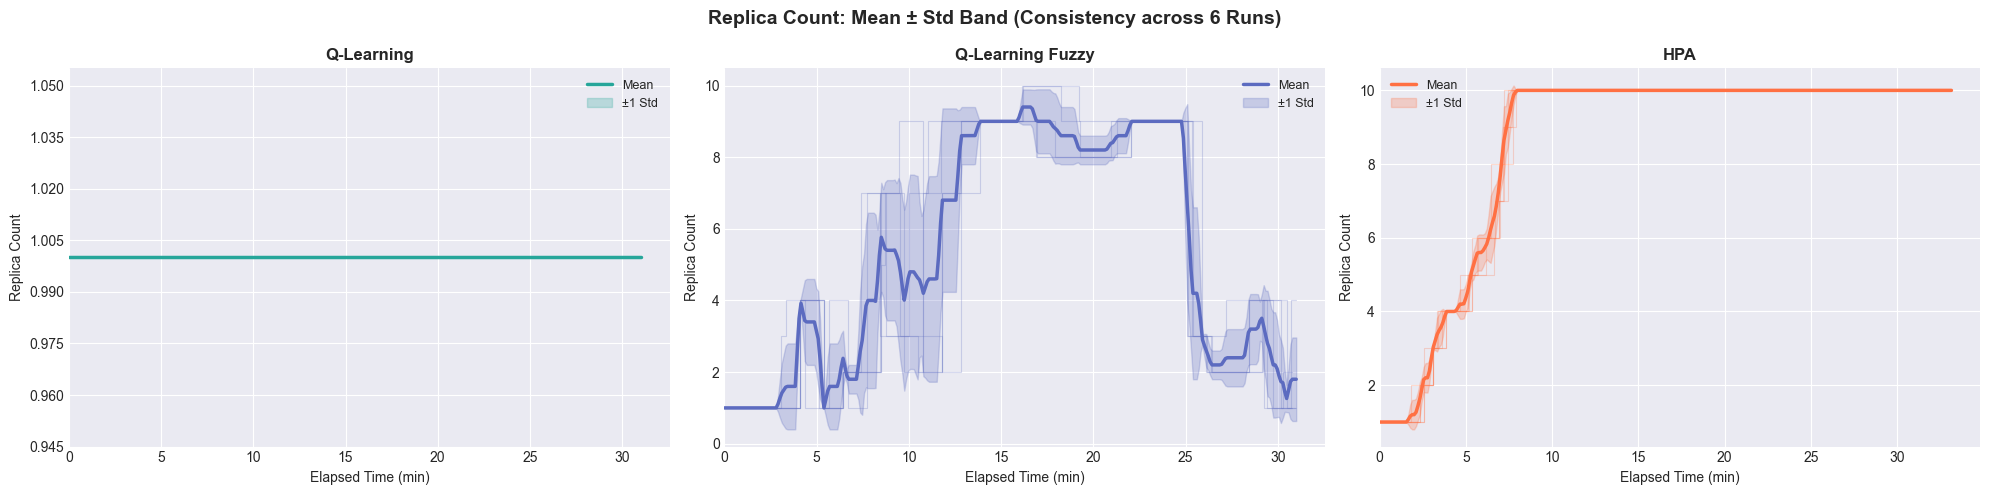

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle('Replica Count: Mean ± Std Band (Consistency across 6 Runs)', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    dfs = ALL_DATA[method]
    base_color = METHOD_BASE_COLOR[method]

    # Buat grid waktu seragam
    max_duration = max(df['elapsed_min'].iloc[-1] for df in dfs)
    t_grid = np.linspace(0, max_duration, 300)

    # Interpolasi setiap run ke grid waktu
    interp_matrix = []
    for df in dfs:
        interp_vals = np.interp(t_grid, df['elapsed_min'], df['replica_state'])
        interp_matrix.append(interp_vals)
    interp_matrix = np.array(interp_matrix)

    mean_vals = interp_matrix.mean(axis=0)
    std_vals  = interp_matrix.std(axis=0)

    # Plot individual runs (tipis & transparan)
    for i, df in enumerate(dfs):
        ax.step(df['elapsed_min'], df['replica_state'], where='post',
                linewidth=0.8, alpha=0.25, color=base_color)

    # Plot mean
    ax.plot(t_grid, mean_vals, linewidth=2.5, color=base_color, label='Mean')
    # Std band
    ax.fill_between(t_grid, mean_vals - std_vals, mean_vals + std_vals,
                    alpha=0.25, color=base_color, label='±1 Std')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (min)')
    ax.set_ylabel('Replica Count')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 5. Pattern SLO (Response Time)

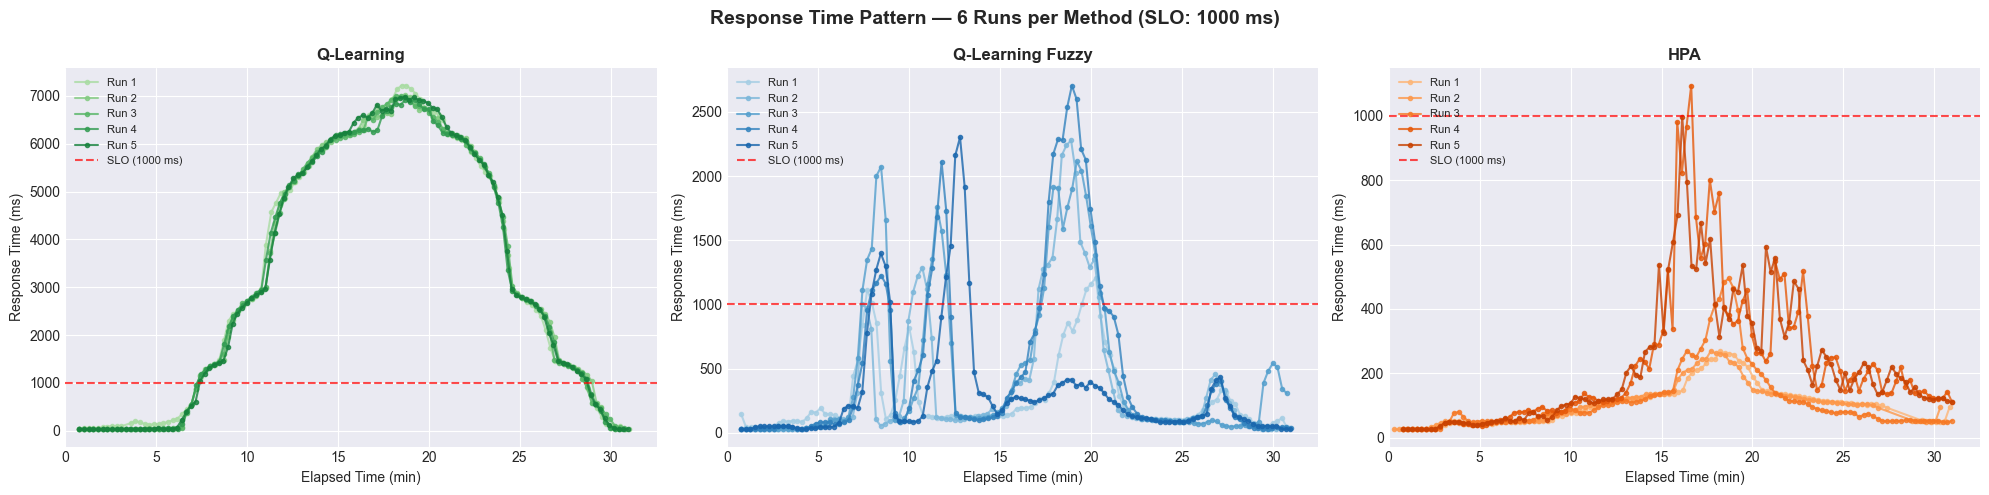

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle(f'Response Time Pattern — 6 Runs per Method (SLO: {SLO_THRESHOLD} ms)', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]

    for i, df in enumerate(dfs):
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        if mask.sum() == 0:
            continue
        ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
                marker='o', markersize=3, linewidth=1.5,
                alpha=0.8, color=colors[i], label=f'Run {i+1}')

    ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (min)')
    ax.set_ylabel('Response Time (ms)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 6. Pattern SLO (Response Time) — Mean ± Std Band

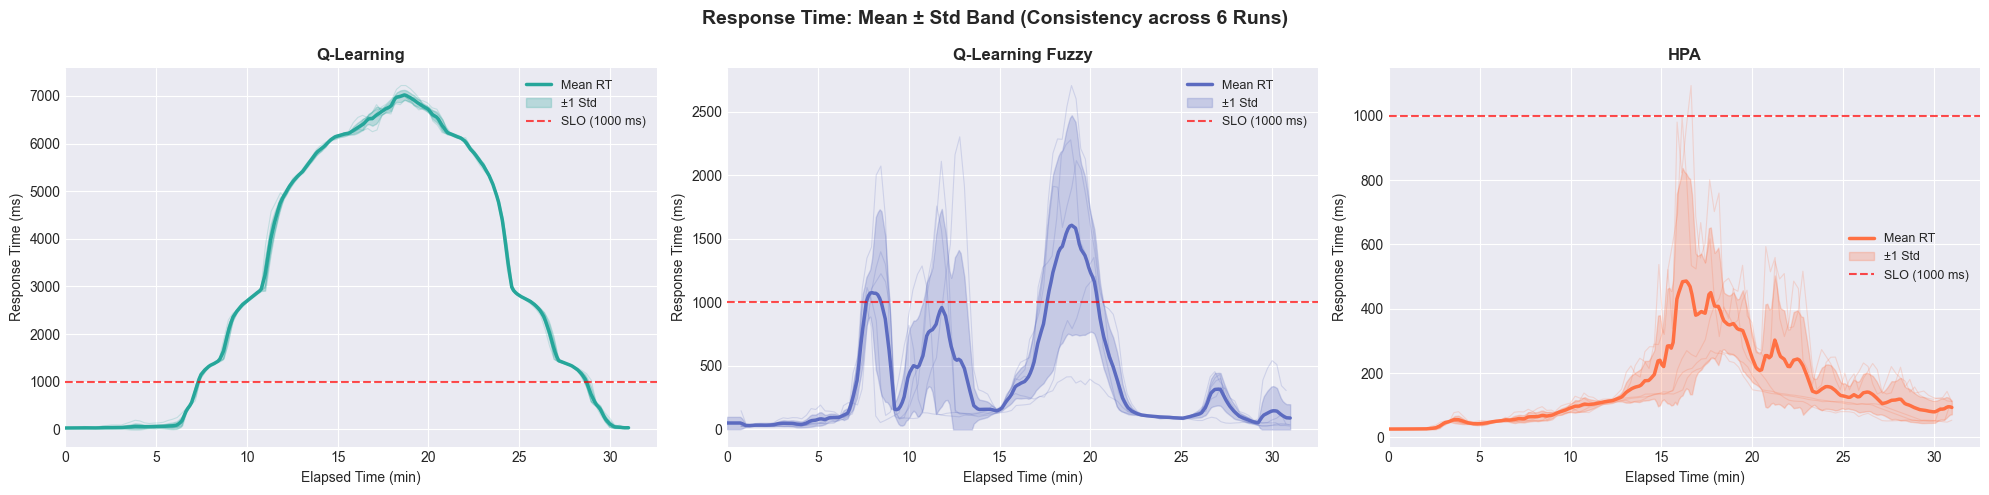

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle('Response Time: Mean ± Std Band (Consistency across 6 Runs)', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    dfs = ALL_DATA[method]
    base_color = METHOD_BASE_COLOR[method]

    # Kumpulkan semua data RT yang valid
    valid_dfs = []
    for df in dfs:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        if mask.sum() > 0:
            valid_dfs.append(df[mask][['elapsed_min', 'response_time_ms']].copy())

    if valid_dfs:
        max_t = max(d['elapsed_min'].iloc[-1] for d in valid_dfs)
        t_grid = np.linspace(0, max_t, 300)

        interp_matrix = []
        for d in valid_dfs:
            interp_vals = np.interp(t_grid, d['elapsed_min'], d['response_time_ms'])
            interp_matrix.append(interp_vals)
        interp_matrix = np.array(interp_matrix)

        mean_rt = interp_matrix.mean(axis=0)
        std_rt  = interp_matrix.std(axis=0)

        # Individual runs (transparan)
        for d in valid_dfs:
            ax.plot(d['elapsed_min'], d['response_time_ms'],
                    linewidth=0.8, alpha=0.2, color=base_color)

        ax.plot(t_grid, mean_rt, linewidth=2.5, color=base_color, label='Mean RT')
        ax.fill_between(t_grid, np.maximum(0, mean_rt - std_rt), mean_rt + std_rt,
                        alpha=0.25, color=base_color, label='±1 Std')

    ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (min)')
    ax.set_ylabel('Response Time (ms)')
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 7. Grid Pattern: Replica & SLO

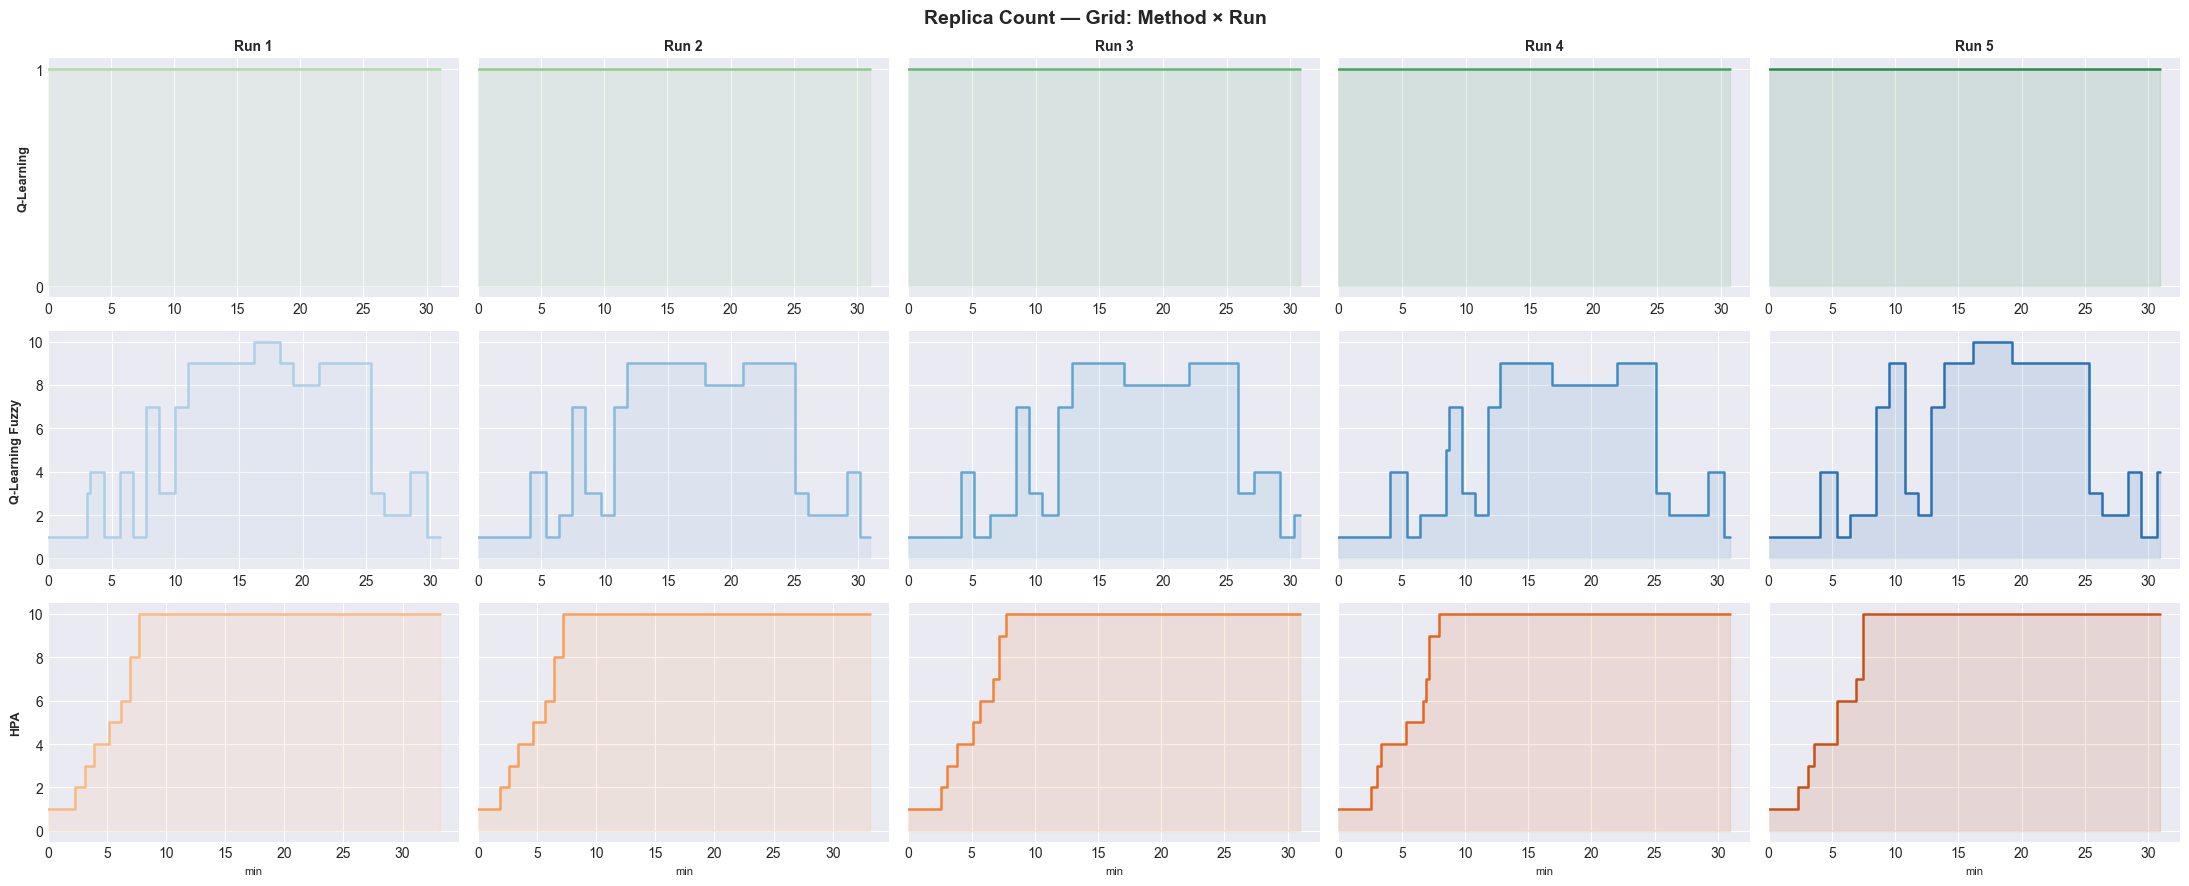

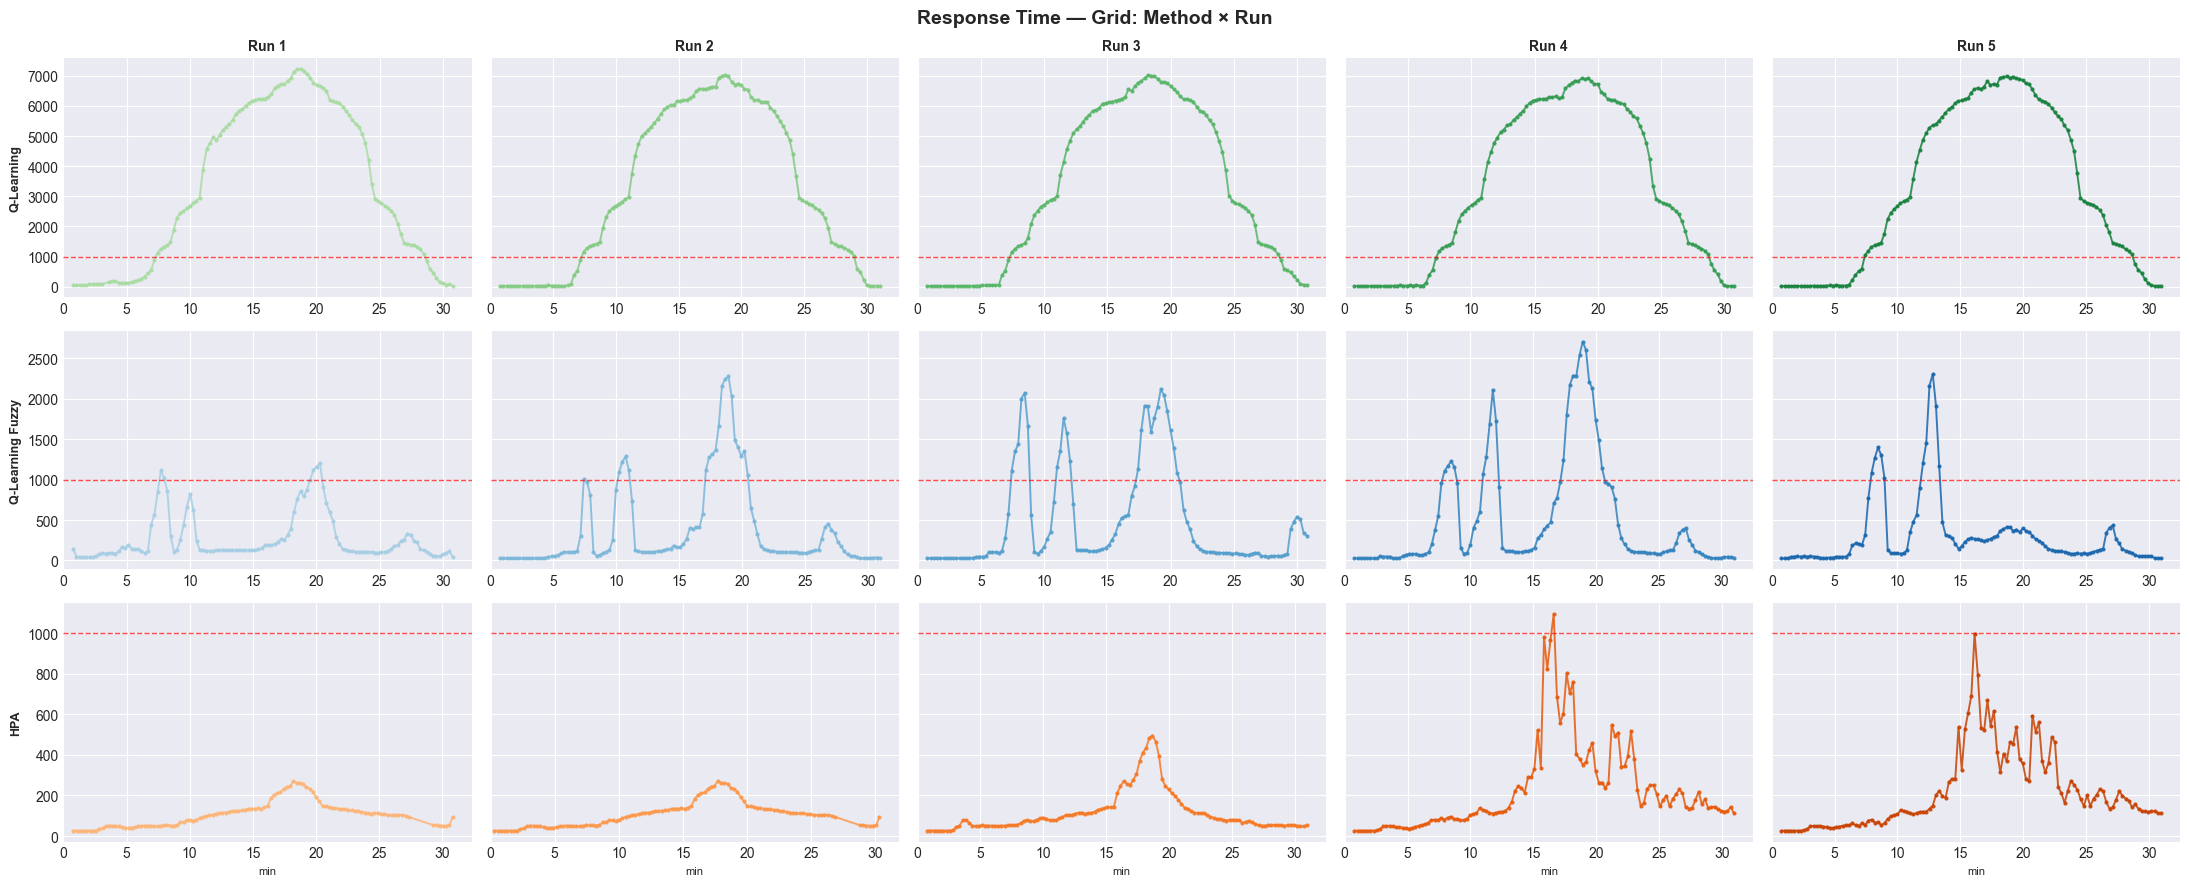

In [7]:
N_RUNS = 5

# ── Replica Count Grid ──────────────────────────────────────────
fig, axes = plt.subplots(3, N_RUNS, figsize=(22, 9), sharey='row')
fig.suptitle('Replica Count — Grid: Method × Run', fontsize=14, fontweight='bold')

for row, method in enumerate(methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]
    for col in range(N_RUNS):
        ax = axes[row, col]
        df = dfs[col] if col < len(dfs) else None
        if df is not None:
            ax.step(df['elapsed_min'], df['replica_state'], where='post',
                    linewidth=1.8, color=colors[col], alpha=0.9)
            ax.fill_between(df['elapsed_min'], 0, df['replica_state'],
                            step='post', alpha=0.12, color=colors[col])
            ax.set_xlim(left=0)
            ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        if row == 0:
            ax.set_title(f'Run {col+1}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(method, fontsize=9, fontweight='bold')
        if row == 2:
            ax.set_xlabel('min', fontsize=8)

plt.tight_layout()
plt.show()

# ── Response Time Grid ───────────────────────────────────────────
fig, axes = plt.subplots(3, N_RUNS, figsize=(22, 9), sharey='row')
fig.suptitle('Response Time — Grid: Method × Run', fontsize=14, fontweight='bold')

for row, method in enumerate(methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]
    for col in range(N_RUNS):
        ax = axes[row, col]
        df = dfs[col] if col < len(dfs) else None
        if df is not None:
            mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
            if mask.sum() > 0:
                ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
                        marker='o', markersize=2, linewidth=1.4,
                        color=colors[col], alpha=0.85)
            ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
                       linewidth=1.0, alpha=0.7)
            ax.set_xlim(left=0)
        if row == 0:
            ax.set_title(f'Run {col+1}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(method, fontsize=9, fontweight='bold')
        if row == 2:
            ax.set_xlabel('min', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Comparison Method — Mean Pattern

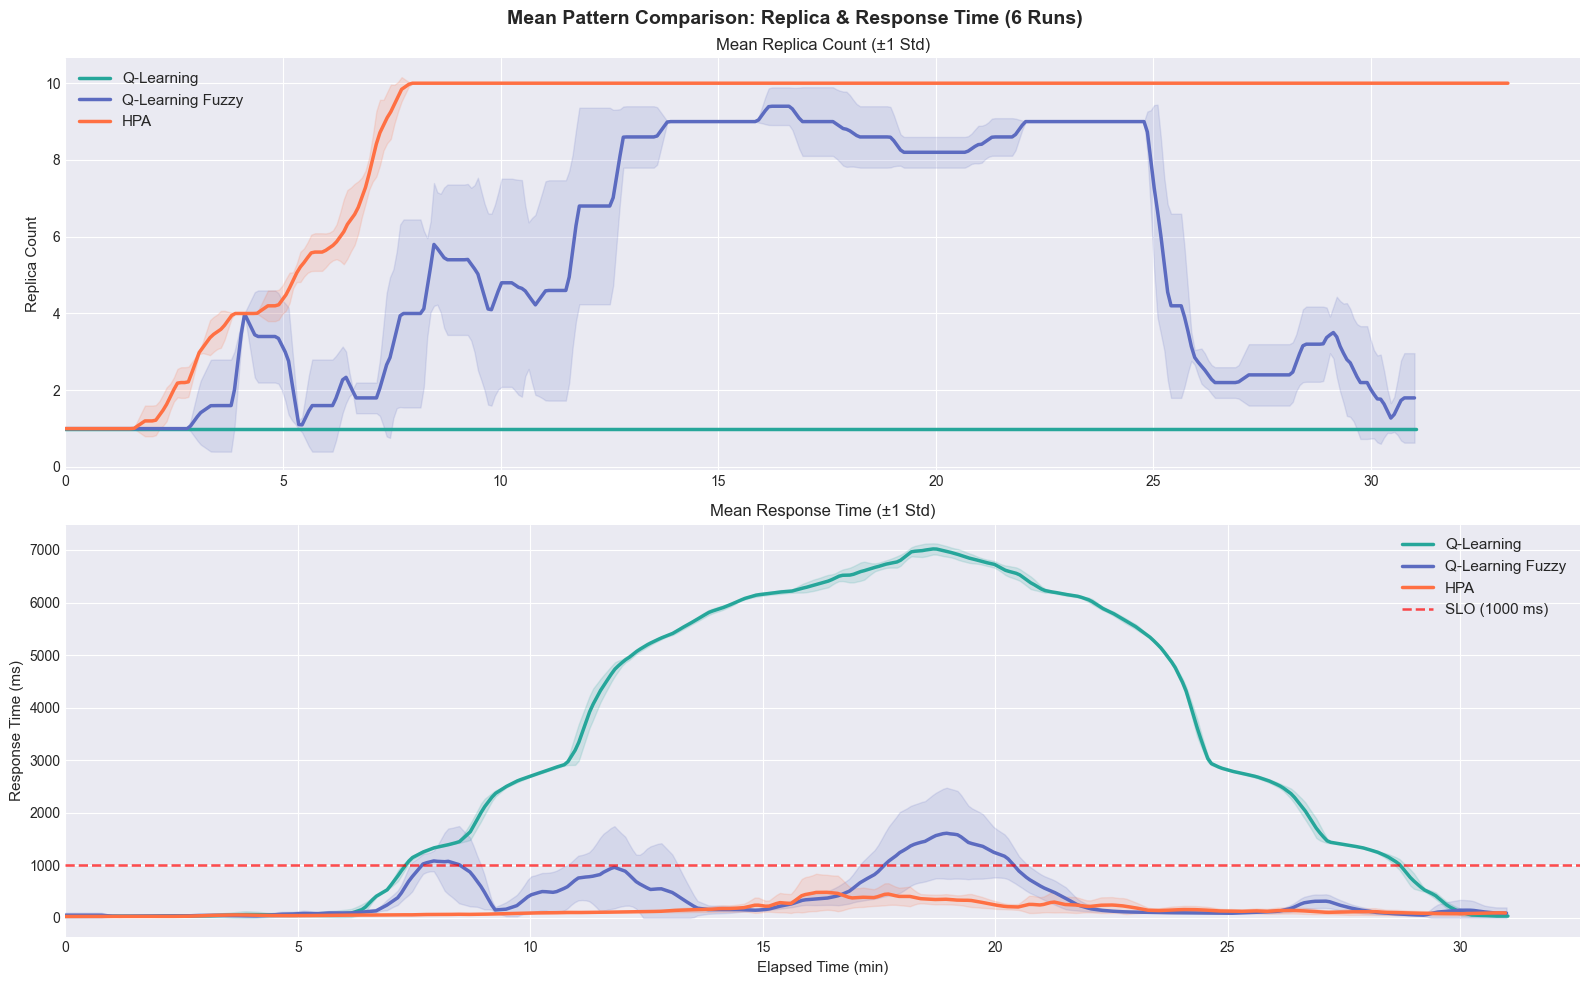

In [8]:
fig, (ax_rep, ax_rt) = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Mean Pattern Comparison: Replica & Response Time (6 Runs)', fontsize=14, fontweight='bold')

for method in methods:
    dfs = ALL_DATA[method]
    base_color = METHOD_BASE_COLOR[method]

    # ── Replica ──────────────────────────────────────────────────
    max_t = max(df['elapsed_min'].iloc[-1] for df in dfs)
    t_grid = np.linspace(0, max_t, 400)
    rep_matrix = np.array([
        np.interp(t_grid, df['elapsed_min'], df['replica_state'])
        for df in dfs
    ])
    mean_rep = rep_matrix.mean(axis=0)
    std_rep  = rep_matrix.std(axis=0)

    ax_rep.plot(t_grid, mean_rep, linewidth=2.5, color=base_color, label=method)
    ax_rep.fill_between(t_grid, mean_rep - std_rep, mean_rep + std_rep,
                        alpha=0.15, color=base_color)

    # ── Response Time ─────────────────────────────────────────────
    valid_dfs = [] 
    for df in dfs:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        if mask.sum() > 0:
            valid_dfs.append(df[mask][['elapsed_min', 'response_time_ms']].copy())

    if valid_dfs:
        max_t_rt = max(d['elapsed_min'].iloc[-1] for d in valid_dfs)
        t_grid_rt = np.linspace(0, max_t_rt, 400)
        rt_matrix = np.array([
            np.interp(t_grid_rt, d['elapsed_min'], d['response_time_ms'])
            for d in valid_dfs
        ])
        mean_rt = rt_matrix.mean(axis=0)
        std_rt  = rt_matrix.std(axis=0)

        ax_rt.plot(t_grid_rt, mean_rt, linewidth=2.5, color=base_color, label=method)
        ax_rt.fill_between(t_grid_rt, np.maximum(0, mean_rt - std_rt), mean_rt + std_rt,
                           alpha=0.15, color=base_color)

ax_rep.set_ylabel('Replica Count', fontsize=11)
ax_rep.set_title('Mean Replica Count (±1 Std)', fontsize=12)
ax_rep.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_rep.legend(fontsize=11)
ax_rep.set_xlim(left=0)

ax_rt.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
              linewidth=1.8, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
ax_rt.set_ylabel('Response Time (ms)', fontsize=11)
ax_rt.set_xlabel('Elapsed Time (min)', fontsize=11)
ax_rt.set_title('Mean Response Time (±1 Std)', fontsize=12)
ax_rt.legend(fontsize=11)
ax_rt.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 9. Summary Statistics Method

In [9]:
records = []

for method, dfs in ALL_DATA.items():
    for i, df in enumerate(dfs):
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
        rep = df['replica_state']
        n_total = len(rt)
        n_viol  = (rt > SLO_THRESHOLD).sum() if n_total > 0 else 0
        records.append({
            'Method': method,
            'Run': i + 1,
            'Duration (s)': df['elapsed_s'].iloc[-1],
            'Replica Mean': rep.mean(),
            'Replica Min':  rep.min(),
            'Replica Max':  rep.max(),
            'RT Mean (ms)': rt.mean() if n_total > 0 else float('nan'),
            'RT Median':    rt.median() if n_total > 0 else float('nan'),
            'RT Max (ms)':  rt.max() if n_total > 0 else float('nan'),
            'SLO Violations': n_viol,
            'SLO Total':      n_total,
            'Violation %':    n_viol / n_total * 100 if n_total > 0 else float('nan'),
        })

summary_df = pd.DataFrame(records)

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(summary_df.to_string(index=False))

          Method  Run  Duration (s)  Replica Mean  Replica Min  Replica Max  RT Mean (ms)  RT Median  RT Max (ms)  SLO Violations  SLO Total  Violation %
      Q-Learning    1       1862.34          1.00            1            1       3281.65    2762.52      7217.90              83        117        70.94
      Q-Learning    2       1861.59          1.00            1            1       3198.94    2748.77      7019.62              85        119        71.43
      Q-Learning    3       1845.44          1.00            1            1       3214.82    2758.69      7009.09              83        118        70.34
      Q-Learning    4       1844.56          1.00            1            1       3215.92    2761.40      6917.22              84        118        71.19
      Q-Learning    5       1857.89          1.00            1            1       3200.80    2750.75      6984.13              84        119        70.59
Q-Learning Fuzzy    1       1845.79          5.65            1           10 

In [10]:
# Agregasi per metode (rata-rata dari 6 run)
agg_cols = ['Replica Mean', 'Replica Min', 'Replica Max',
            'RT Mean (ms)', 'RT Median', 'RT Max (ms)',
            'SLO Violations', 'Violation %']

agg_df = summary_df.groupby('Method')[agg_cols].agg(['mean', 'std']).round(2)
agg_df.columns = [f'{c[0]} ({c[1]})' for c in agg_df.columns]

print('\n=== Aggregation per Method (Mean ± Std across 6 Runs) ===')
print(agg_df.to_string())


=== Aggregation per Method (Mean ± Std across 6 Runs) ===
                  Replica Mean (mean)  Replica Mean (std)  Replica Min (mean)  Replica Min (std)  Replica Max (mean)  Replica Max (std)  RT Mean (ms) (mean)  RT Mean (ms) (std)  RT Median (mean)  RT Median (std)  RT Max (ms) (mean)  RT Max (ms) (std)  SLO Violations (mean)  SLO Violations (std)  Violation % (mean)  Violation % (std)
Method                                                                                                                                                                                                                                                                                                                                        
HPA                              8.45                0.07                1.00               0.00               10.00               0.00               154.18               62.12            115.73            29.05              625.20             395.97                   0.

## 10. Boxplot Distribution: Replica & SLO

C:\Users\indra\AppData\Local\Temp\ipykernel_25112\2107452251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rep_data, labels=bp_labels, patch_artist=True,
C:\Users\indra\AppData\Local\Temp\ipykernel_25112\2107452251.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rt_data, labels=bp_labels, patch_artist=True,


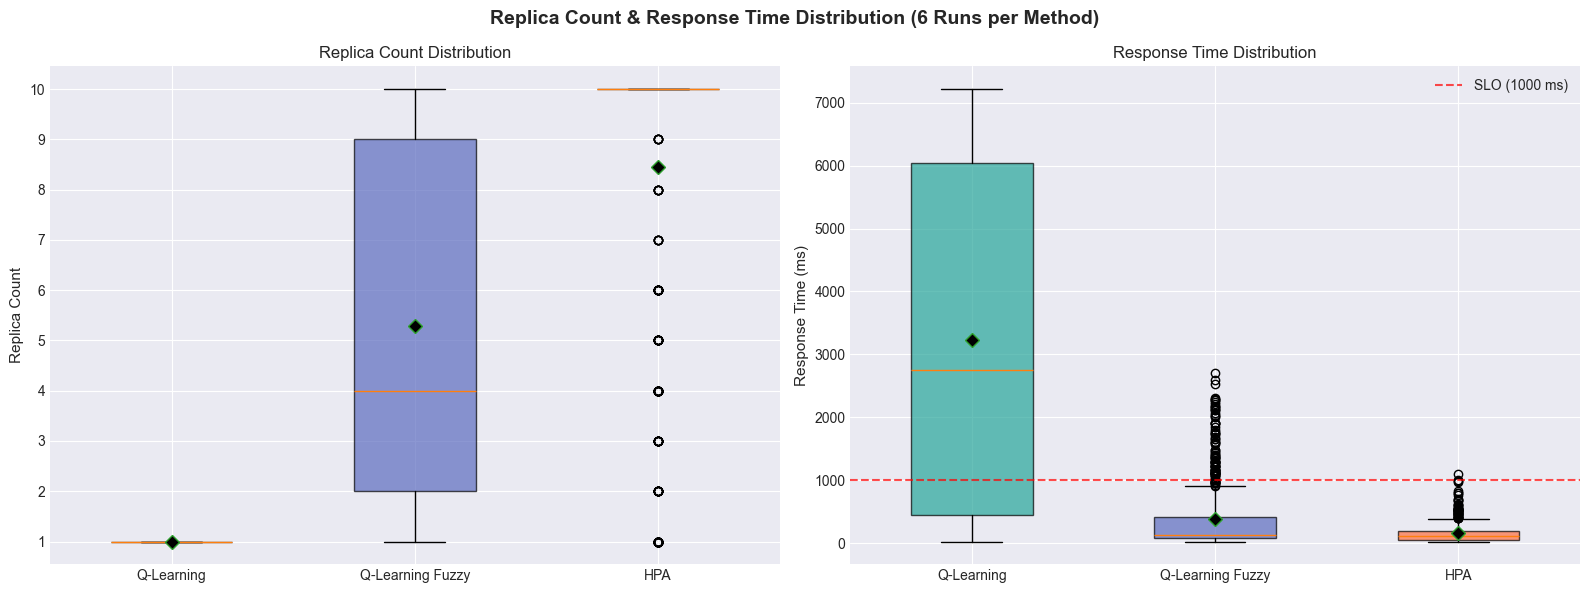

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Replica Count & Response Time Distribution (6 Runs per Method)', fontsize=14, fontweight='bold')

bp_labels = methods
bp_colors = [METHOD_BASE_COLOR[m] for m in methods]

# ── Replica Count Boxplot ───────────────────────────────────────
ax = axes[0]
rep_data = [
    pd.concat([df['replica_state'] for df in ALL_DATA[m]]).values
    for m in methods
]
bp = ax.boxplot(rep_data, labels=bp_labels, patch_artist=True,
                widths=0.5, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 7})
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Replica Count', fontsize=11)
ax.set_title('Replica Count Distribution', fontsize=12)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# ── Response Time Boxplot ────────────────────────────────────────
ax = axes[1]
rt_data = []
for m in methods:
    all_rt = []
    for df in ALL_DATA[m]:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        all_rt.extend(df.loc[mask, 'response_time_ms'].tolist())
    rt_data.append(np.array(all_rt))

bp = ax.boxplot(rt_data, labels=bp_labels, patch_artist=True,
                widths=0.5, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 7})
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
           linewidth=1.5, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
ax.set_ylabel('Response Time (ms)', fontsize=11)
ax.set_title('Response Time Distribution', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 11. SLO Violation Rate per Run (Heatmap)

## 12. Significance Test: Konsistensi Pattern per Metode (Kruskal-Wallis)

Uji apakah 6 run dalam setiap metode memiliki **distribusi yang sama** (pattern konsisten).

- **H₀**: Semua run dalam satu metode berasal dari distribusi yang sama (pattern konsisten)
- **H₁**: Setidaknya satu run berbeda secara signifikan
- Threshold signifikansi: **α = 0.05**
- p-value **> 0.05** → gagal tolak H₀ → pattern **konsisten** antar run
- p-value **≤ 0.05** → tolak H₀ → ada perbedaan signifikan antar run

---

### Cara Kerja Kruskal-Wallis

**Kruskal-Wallis** adalah uji non-parametrik satu arah (one-way) untuk membandingkan distribusi **lebih dari dua kelompok** secara serentak.

**Langkah kerjanya:**
1. Gabungkan semua data dari seluruh kelompok (6 run), lalu **ranking** setiap nilai dari terkecil ke terbesar
2. Hitung **rata-rata rank** per kelompok
3. Hitung **H-statistic** yang mengukur seberapa jauh rata-rata rank tiap kelompok menyimpang dari rata-rata rank keseluruhan
4. H-statistic mengikuti distribusi **Chi-squared** (df = jumlah kelompok − 1) → menghasilkan p-value

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

di mana $N$ = total data, $k$ = jumlah kelompok, $R_i$ = jumlah rank kelompok $i$, $n_i$ = ukuran kelompok $i$.

**Mengapa Kruskal-Wallis?**
- Data replica count dan response time **tidak terdistribusi normal** (skewed, diskrit)
- Kruskal-Wallis **tidak mengasumsikan normalitas** — bekerja berdasarkan rank, bukan nilai asli
- Lebih tepat dibanding ANOVA parametrik untuk data time-series eksperimen seperti ini
- Mampu membandingkan **6 kelompok sekaligus** dalam satu uji, tanpa perlu uji berpasangan satu per satu

Kruskal-Wallis Test — Pattern Consistency per Method (α=0.05)
                 Replica H-stat  Replica p-value          Replica Verdict  RT H-stat  RT p-value            RT Verdict
Method                                                                                                                
Q-Learning                    -             1.00  Konsisten ✓ (identical)       0.99        0.91           Konsisten ✓
Q-Learning Fuzzy           4.74             0.32              Konsisten ✓       2.51        0.64           Konsisten ✓
HPA                        0.29             0.99              Konsisten ✓      52.04        0.00  Berbeda Signifikan ✗



C:\Users\indra\AppData\Local\Temp\ipykernel_25112\3844099568.py:89: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\indra\AppData\Local\Temp\ipykernel_25112\3844099568.py:89: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\indra\Documents\Projects\autoscaling-k8s-reinforcement-learning\analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\indra\Documents\Projects\autoscaling-k8s-reinforcement-learning\analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


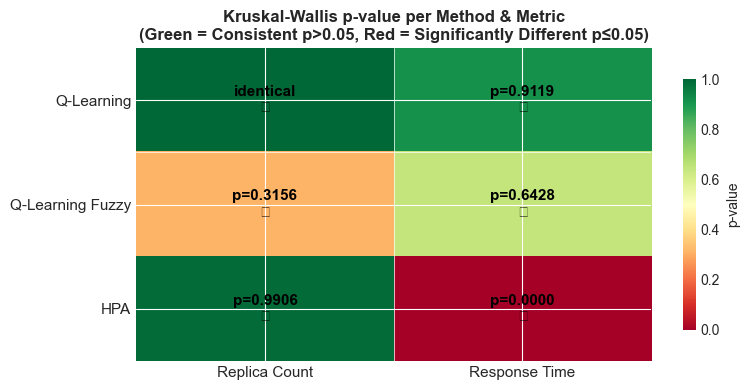


Summary:
  Q-Learning           | Replica: Konsisten ✓ (identical)        | RT: Konsisten ✓
  Q-Learning Fuzzy     | Replica: Konsisten ✓                    | RT: Konsisten ✓
  HPA                  | Replica: Konsisten ✓                    | RT: Berbeda Signifikan ✗


In [12]:
from scipy import stats

ALPHA = 0.05

results = []

for method, dfs in ALL_DATA.items():
    # ── Replica Count ─────────────────────────────────────────────
    rep_groups = [df['replica_state'].values for df in dfs]
    all_identical = all(np.std(g) == 0 for g in rep_groups) and len(set(np.concatenate(rep_groups))) == 1

    if all_identical:
        # Semua run punya nilai konstan yang sama → pattern paling konsisten
        stat_rep, p_rep = np.nan, 1.0
        verdict_rep = 'Konsisten ✓ (identical)'
    else:
        try:
            stat_rep, p_rep = stats.kruskal(*rep_groups)
            verdict_rep = 'Konsisten ✓' if p_rep > ALPHA else 'Berbeda Signifikan ✗'
        except Exception:
            stat_rep, p_rep = np.nan, np.nan
            verdict_rep = 'N/A'

    # ── Response Time ─────────────────────────────────────────────
    rt_groups = []
    for df in dfs:
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms'].values
        rt_groups.append(rt)

    try:
        stat_rt, p_rt = stats.kruskal(*rt_groups)
        verdict_rt = 'Konsisten ✓' if p_rt > ALPHA else 'Berbeda Signifikan ✗'
    except Exception:
        stat_rt, p_rt = np.nan, np.nan
        verdict_rt = 'N/A'

    results.append({
        'Method':           method,
        'Replica H-stat':   round(stat_rep, 4) if not np.isnan(stat_rep) else '-',
        'Replica p-value':  round(p_rep, 4)    if not np.isnan(p_rep)   else '-',
        'Replica Verdict':  verdict_rep,
        'RT H-stat':        round(stat_rt, 4)  if not np.isnan(stat_rt)  else '-',
        'RT p-value':       round(p_rt, 4)     if not np.isnan(p_rt)     else '-',
        'RT Verdict':       verdict_rt,
    })

result_df = pd.DataFrame(results).set_index('Method')

print(f'Kruskal-Wallis Test — Pattern Consistency per Method (α={ALPHA})')
print('=' * 90)
print(result_df.to_string())
print()

# ── Visualisasi p-value heatmap ───────────────────────────────────
p_matrix = np.array([
    [
        float(r['Replica p-value']) if isinstance(r['Replica p-value'], (int, float)) else np.nan,
        float(r['RT p-value'])      if isinstance(r['RT p-value'], (int, float))      else np.nan,
    ]
    for r in results
])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(p_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='p-value', shrink=0.8)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Replica Count', 'Response Time'], fontsize=11)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=11)
ax.set_title(f'Kruskal-Wallis p-value per Method & Metric\n(Green = Consistent p>{ALPHA}, Red = Significantly Different p≤{ALPHA})',
             fontsize=12, fontweight='bold')

# Anotasi nilai & verdict
for row in range(len(methods)):
    for col in range(2):
        val = p_matrix[row, col]
        if not np.isnan(val):
            verdict = '✓' if val > ALPHA else '✗'
            label = f'p={val:.4f}\n{verdict}' if val < 1.0 else f'identical\n✓'
            ax.text(col, row, label,
                    ha='center', va='center', fontsize=11, fontweight='bold', color='black')
        else:
            ax.text(col, row, 'N/A', ha='center', va='center', fontsize=11, color='gray')

ax.axhline(0.5, color='white', linewidth=0.5)
ax.axvline(0.5, color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

# ── Ringkasan interpretasi ────────────────────────────────────────
print('\nSummary:')
for r in results:
    print(f"  {r['Method']:<20} | Replica: {r['Replica Verdict']:<30} | RT: {r['RT Verdict']}")

### 12.2 Uji Signifikansi RT < SLO (1000 ms)

Uji apakah response time setiap run **secara signifikan berada di bawah SLO**.

- **H₀**: median RT ≥ 1000 ms (tidak memenuhi SLO)
- **H₁**: median RT < 1000 ms (memenuhi SLO secara signifikan)
- Uji: **Wilcoxon Signed-Rank** one-sample, one-tailed (less), α = 0.05

---

### Cara Kerja Wilcoxon Signed-Rank (One-Sample)

**Wilcoxon Signed-Rank** adalah uji non-parametrik untuk menguji apakah **median suatu populasi** berbeda dari nilai referensi tertentu — dalam hal ini SLO = 1000 ms.

**Langkah kerjanya:**
1. **Hitung selisih** setiap observasi terhadap nilai referensi: $d_i = RT_i - 1000$
2. **Buang** data yang $d_i = 0$ (tepat di SLO)
3. **Ranking** nilai absolut $|d_i|$ dari terkecil ke terbesar
4. Beri tanda positif/negatif ke rank sesuai tanda $d_i$
5. Hitung **W-statistic** = jumlah rank dengan tanda positif (RT > SLO)
6. Karena uji *one-tailed less*, p-value dihitung dari probabilitas W sekecil atau lebih kecil dari nilai observasi → p kecil berarti mayoritas data **di bawah** SLO

**Mengapa Wilcoxon Signed-Rank?**
- Alternatif non-parametrik dari **one-sample t-test** — tidak memerlukan asumsi distribusi normal
- Response time sering **right-skewed** (ada lonjakan ekstrem sesekali), sehingga t-test bisa misleading
- Uji berbasis **rank** lebih robust terhadap outlier
- Cocok untuk menjawab pertanyaan: *"apakah secara keseluruhan sistem beroperasi di bawah batas SLO?"*
- One-tailed karena arah hipotesis sudah jelas: kita hanya peduli apakah RT **lebih rendah** dari SLO, bukan sekadar berbeda

Wilcoxon Signed-Rank Test: H₁ = median RT < 1000 ms  (α=0.05)

Q-Learning  (0/5 run significantly below SLO)
 Run  Median RT  W-stat  p-value            Verdict
   1    2762.50 5886.00     1.00 Tidak signifikan ✗
   2    2748.80 6040.00     1.00 Tidak signifikan ✗
   3    2758.70 5969.00     1.00 Tidak signifikan ✗
   4    2761.40 5987.00     1.00 Tidak signifikan ✗
   5    2750.70 6014.00     1.00 Tidak signifikan ✗

Q-Learning Fuzzy  (5/5 run significantly below SLO)
 Run  Median RT  W-stat  p-value        Verdict
   1     133.20   34.00     0.00 Di bawah SLO ✓
   2     113.90  647.00     0.00 Di bawah SLO ✓
   3     124.60 1037.00     0.00 Di bawah SLO ✓
   4     124.70 1295.00     0.00 Di bawah SLO ✓
   5     144.50  368.00     0.00 Di bawah SLO ✓

HPA  (5/5 run significantly below SLO)
 Run  Median RT  W-stat  p-value        Verdict
   1     104.00    0.00     0.00 Di bawah SLO ✓
   2     104.00    0.00     0.00 Di bawah SLO ✓
   3      79.60    0.00     0.00 Di bawah SLO ✓
   4  

C:\Users\indra\AppData\Local\Temp\ipykernel_25112\1902614398.py:76: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\indra\AppData\Local\Temp\ipykernel_25112\1902614398.py:76: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\indra\Documents\Projects\autoscaling-k8s-reinforcement-learning\analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\indra\Documents\Projects\autoscaling-k8s-reinforcement-learning\analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


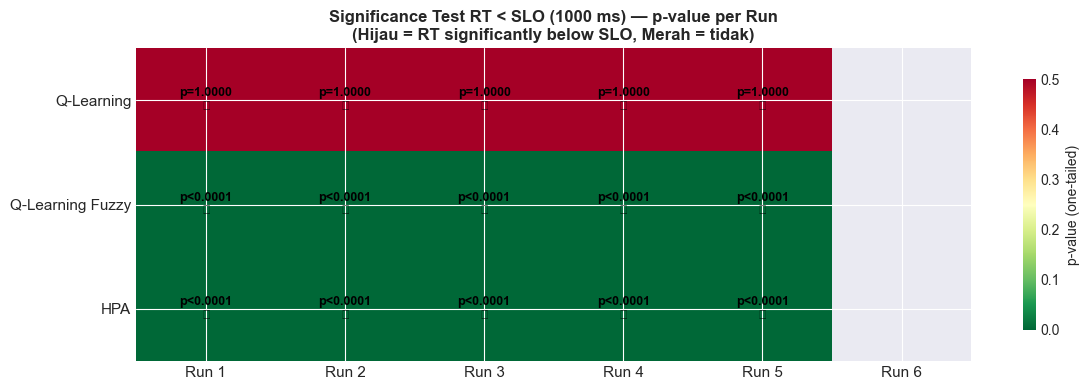


Summary per Method:
  Q-Learning           → ✗ Tidak ada run has RT significantly below SLO
  Q-Learning Fuzzy     → ⚠ 5/6 run has RT significantly below SLO
  HPA                  → ⚠ 5/6 run has RT significantly below SLO


In [13]:
from scipy import stats

ALPHA = 0.05

slo_results = []

for method, dfs in ALL_DATA.items():
    for i, df in enumerate(dfs):
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms'].values

        if len(rt) == 0:
            slo_results.append({'Method': method, 'Run': i+1, 'Median RT': np.nan,
                                 'Stat': np.nan, 'p-value': np.nan, 'Verdict': 'N/A'})
            continue

        median_rt = np.median(rt)

        # Wilcoxon signed-rank one-sample: shift data by SLO_THRESHOLD, test < 0
        shifted = rt - SLO_THRESHOLD
        try:
            stat, p_two = stats.wilcoxon(shifted, alternative='less')
            p_val = p_two
        except ValueError:
            # Semua nilai identik
            stat, p_val = np.nan, (0.0 if median_rt < SLO_THRESHOLD else 1.0)

        verdict = 'Di bawah SLO ✓' if p_val <= ALPHA else 'Tidak signifikan ✗'

        slo_results.append({
            'Method':    method,
            'Run':       i + 1,
            'Median RT': round(median_rt, 1),
            'W-stat':    round(stat, 1) if not np.isnan(stat) else '-',
            'p-value':   round(p_val, 6),
            'Verdict':   verdict,
        })

slo_df = pd.DataFrame(slo_results)

print(f'Wilcoxon Signed-Rank Test: H₁ = median RT < {SLO_THRESHOLD} ms  (α={ALPHA})')
print('=' * 80)
for method in methods:
    sub = slo_df[slo_df['Method'] == method]
    n_pass = (sub['Verdict'].str.startswith('Di bawah')).sum()
    print(f'\n{method}  ({n_pass}/{len(sub)} run significantly below SLO)')
    print(sub.drop(columns='Method').to_string(index=False))

# ── Heatmap p-value per run × metode ─────────────────────────────
N_RUNS = 6
p_mat = np.full((len(methods), N_RUNS), np.nan)
for row, method in enumerate(methods):
    sub = slo_df[slo_df['Method'] == method].reset_index(drop=True)
    for col in range(len(sub)):
        p_mat[row, col] = sub.loc[col, 'p-value']

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(p_mat, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label='p-value (one-tailed)', shrink=0.8)

ax.set_xticks(range(N_RUNS))
ax.set_xticklabels([f'Run {i+1}' for i in range(N_RUNS)], fontsize=11)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=11)
ax.set_title(f'Significance Test RT < SLO ({SLO_THRESHOLD} ms) — p-value per Run\n'
             f'(Hijau = RT significantly below SLO, Merah = tidak)', fontsize=12, fontweight='bold')

for row in range(len(methods)):
    for col in range(N_RUNS):
        val = p_mat[row, col]
        if not np.isnan(val):
            verdict = '✓' if val <= ALPHA else '✗'
            label = f'p={val:.4f}\n{verdict}' if val >= 0.0001 else f'p<0.0001\n{verdict}'
            ax.text(col, row, label, ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# ── Ringkasan per metode ──────────────────────────────────────────
print('\nSummary per Method:')
for method in methods:
    sub = slo_df[slo_df['Method'] == method]
    n_pass = (sub['Verdict'].str.startswith('Di bawah')).sum()
    status = '✓ Semua run' if n_pass == N_RUNS else f'⚠ {n_pass}/{N_RUNS} run' if n_pass > 0 else '✗ Tidak ada run'
    print(f'  {method:<20} → {status} has RT significantly below SLO')

## 13. Uji Hipotesis: Q-Learning Fuzzy vs HPA

**Uji 1 — Replica Count**: Apakah Q-Learning Fuzzy menghasilkan replica **lebih sedikit** dari HPA?
- H₀: median replica QF ≥ median replica HPA
- H₁: median replica QF < median replica HPA
- Uji: **Mann-Whitney U** one-tailed (less), α = 0.05

**Uji 2 — Response Time < SLO**: Apakah RT Q-Learning Fuzzy dan HPA secara signifikan **di bawah 1000 ms**?
- H₀: median RT ≥ 1000 ms
- H₁: median RT < 1000 ms
- Uji: **Wilcoxon Signed-Rank** one-sample, one-tailed (less), α = 0.05

---

### Cara Kerja Mann-Whitney U (Uji 1)

**Mann-Whitney U** adalah uji non-parametrik untuk membandingkan distribusi **dua kelompok independen** — versi non-parametrik dari independent t-test.

**Langkah kerjanya:**
1. Gabungkan data replica QF dan HPA, lalu **ranking** semua nilai
2. Hitung **U-statistic**: untuk setiap pasangan (satu data QF, satu data HPA), hitung berapa kali nilai QF **lebih kecil** dari nilai HPA
3. $U_{QF} = n_{QF} \cdot n_{HPA} + \frac{n_{QF}(n_{QF}+1)}{2} - R_{QF}$, di mana $R_{QF}$ = jumlah rank data QF
4. Karena uji *one-tailed less* (QF < HPA), p-value dihitung dari probabilitas mendapat U sekecil atau lebih kecil dari observasi

**Mengapa Mann-Whitney U?**
- Data replica count **diskrit dan tidak normal** — distribusinya berbentuk tangga (step function)
- Membandingkan **dua metode independen** (QF dan HPA berjalan di kondisi yang sama, bukan pasangan)
- Lebih tepat dari t-test karena tidak mengasumsikan normalitas atau varians yang sama
- One-tailed karena hipotesis penelitian terarah: *"apakah QF lebih hemat resource dari HPA?"*

---

### Cara Kerja Wilcoxon Signed-Rank (Uji 2)

Sama seperti pada **Section 12.2** — menguji apakah median RT suatu metode secara signifikan berada di bawah nilai referensi (SLO = 1000 ms).

Dijalankan **terpisah** untuk QF dan HPA karena keduanya adalah kelompok independen dengan karakteristik RT yang berbeda. Menggabungkannya dalam satu uji akan menyembunyikan perbedaan antar metode.

UJI 1: Replica Count — Q-Learning Fuzzy < HPA?
  Median QF  : 4.00 replica
  Median HPA : 10.00 replica
  U-statistic: 62031.50
  p-value    : 0.000000
  Keputusan  : Tolak H₀ ✓  (QF replica lebih sedikit secara signifikan)

UJI 2: Response Time < SLO (1000 ms)?

  [Q-Learning Fuzzy]
  Median RT  : 128.81 ms
  W-statistic: 16831.00
  p-value    : 0.000000
  Keputusan  : Tolak H₀ ✓  (RT significantly below SLO)

  [HPA]
  Median RT  : 112.16 ms
  W-statistic: 4.00
  p-value    : 0.000000
  Keputusan  : Tolak H₀ ✓  (RT significantly below SLO)


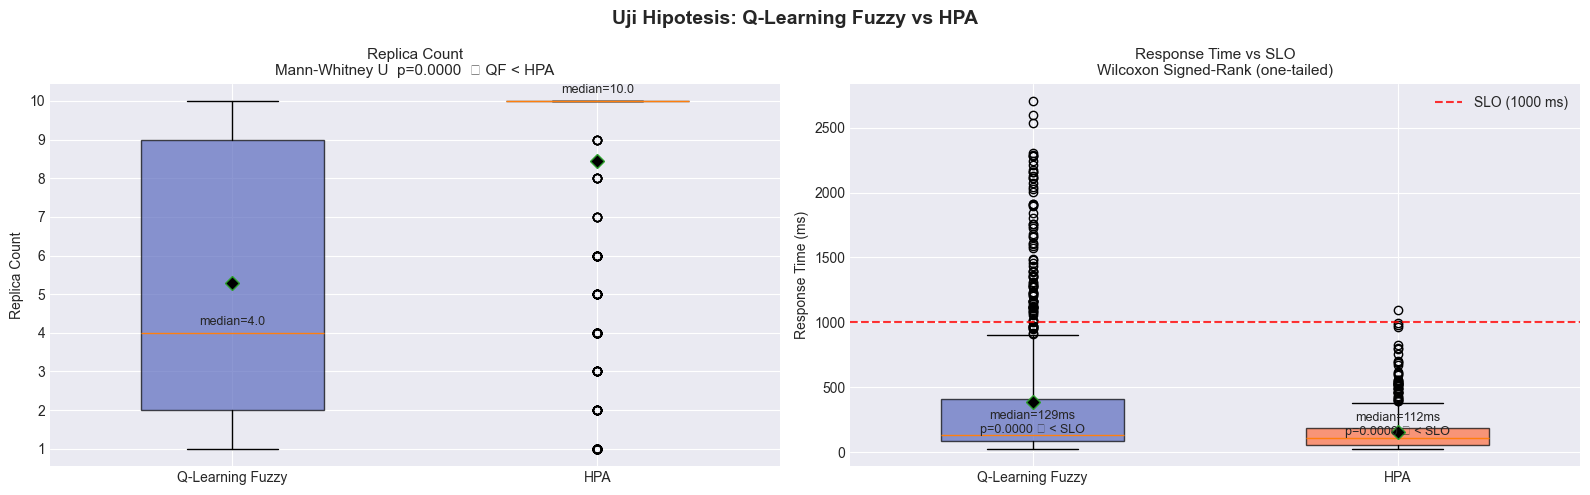

In [14]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

ALPHA = 0.05

# ── Kumpulkan data pooled semua run ───────────────────────────────
def pool_replica(method):
    return np.concatenate([df['replica_state'].values for df in ALL_DATA[method]])

def pool_rt(method):
    all_rt = []
    for df in ALL_DATA[method]:
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms'].values
        all_rt.append(rt)
    return np.concatenate(all_rt)

qf_rep  = pool_replica('Q-Learning Fuzzy')
hpa_rep = pool_replica('HPA')
qf_rt   = pool_rt('Q-Learning Fuzzy')
hpa_rt  = pool_rt('HPA')

print('=' * 65)
print('UJI 1: Replica Count — Q-Learning Fuzzy < HPA?')
print('=' * 65)
u_stat, p_rep = stats.mannwhitneyu(qf_rep, hpa_rep, alternative='less')
verdict_rep = 'Tolak H₀ ✓  (QF replica lebih sedikit secara signifikan)' if p_rep <= ALPHA \
              else 'Gagal tolak H₀ ✗  (tidak cukup bukti QF < HPA)'
print(f'  Median QF  : {np.median(qf_rep):.2f} replica')
print(f'  Median HPA : {np.median(hpa_rep):.2f} replica')
print(f'  U-statistic: {u_stat:.2f}')
print(f'  p-value    : {p_rep:.6f}')
print(f'  Keputusan  : {verdict_rep}')

print()
print('=' * 65)
print(f'UJI 2: Response Time < SLO ({SLO_THRESHOLD} ms)?')
print('=' * 65)
for label, rt_data in [('Q-Learning Fuzzy', qf_rt), ('HPA', hpa_rt)]:
    stat_w, p_rt = stats.wilcoxon(rt_data - SLO_THRESHOLD, alternative='less')
    verdict_rt = 'Tolak H₀ ✓  (RT significantly below SLO)' if p_rt <= ALPHA \
                 else 'Gagal tolak H₀ ✗  (RT tidak terbukti di bawah SLO)'
    print(f'\n  [{label}]')
    print(f'  Median RT  : {np.median(rt_data):.2f} ms')
    print(f'  W-statistic: {stat_w:.2f}')
    print(f'  p-value    : {p_rt:.6f}')
    print(f'  Keputusan  : {verdict_rt}')

# ── Visualisasi ringkasan ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Uji Hipotesis: Q-Learning Fuzzy vs HPA', fontsize=14, fontweight='bold')

# [A] Replica Count boxplot
ax = axes[0]
bp = ax.boxplot([qf_rep, hpa_rep], labels=['Q-Learning Fuzzy', 'HPA'],
                patch_artist=True, showmeans=True, widths=0.5,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 7})
bp['boxes'][0].set_facecolor(METHOD_BASE_COLOR['Q-Learning Fuzzy']); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(METHOD_BASE_COLOR['HPA']);              bp['boxes'][1].set_alpha(0.7)

for i, (data, label) in enumerate([(qf_rep, 'Q-Learning Fuzzy'), (hpa_rep, 'HPA')]):
    ax.text(i + 1, np.median(data) + 0.2, f'median={np.median(data):.1f}', ha='center', fontsize=9)

ax.set_ylabel('Replica Count')
ax.set_title(f'Replica Count\nMann-Whitney U  p={p_rep:.4f}  {"✓ QF < HPA" if p_rep <= ALPHA else "✗ tidak signifikan"}',
             fontsize=11)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# [B] Response Time boxplot
ax = axes[1]
bp = ax.boxplot([qf_rt, hpa_rt], labels=['Q-Learning Fuzzy', 'HPA'],
                patch_artist=True, showmeans=True, widths=0.5,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 7})
bp['boxes'][0].set_facecolor(METHOD_BASE_COLOR['Q-Learning Fuzzy']); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(METHOD_BASE_COLOR['HPA']);              bp['boxes'][1].set_alpha(0.7)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label=f'SLO ({SLO_THRESHOLD} ms)')

_, p_qf_slo  = stats.wilcoxon(qf_rt  - SLO_THRESHOLD, alternative='less')
_, p_hpa_slo = stats.wilcoxon(hpa_rt - SLO_THRESHOLD, alternative='less')
for i, (data, p_val) in enumerate([(qf_rt, p_qf_slo), (hpa_rt, p_hpa_slo)]):
    verdict = '✓ < SLO' if p_val <= ALPHA else '✗ ≥ SLO'
    ax.text(i + 1, np.median(data) + 20, f'median={np.median(data):.0f}ms\np={p_val:.4f} {verdict}',
            ha='center', fontsize=9)

ax.set_ylabel('Response Time (ms)')
ax.set_title('Response Time vs SLO\nWilcoxon Signed-Rank (one-tailed)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 12.1 Deep-Dive: Penyebab Perbedaan Signifikan

Investigasi dua kasus yang ditolak H₀:
- **Q-Learning Fuzzy** — Replica Count berbeda signifikan (p=0.03)
- **HPA** — Response Time berbeda signifikan (p=0.00)

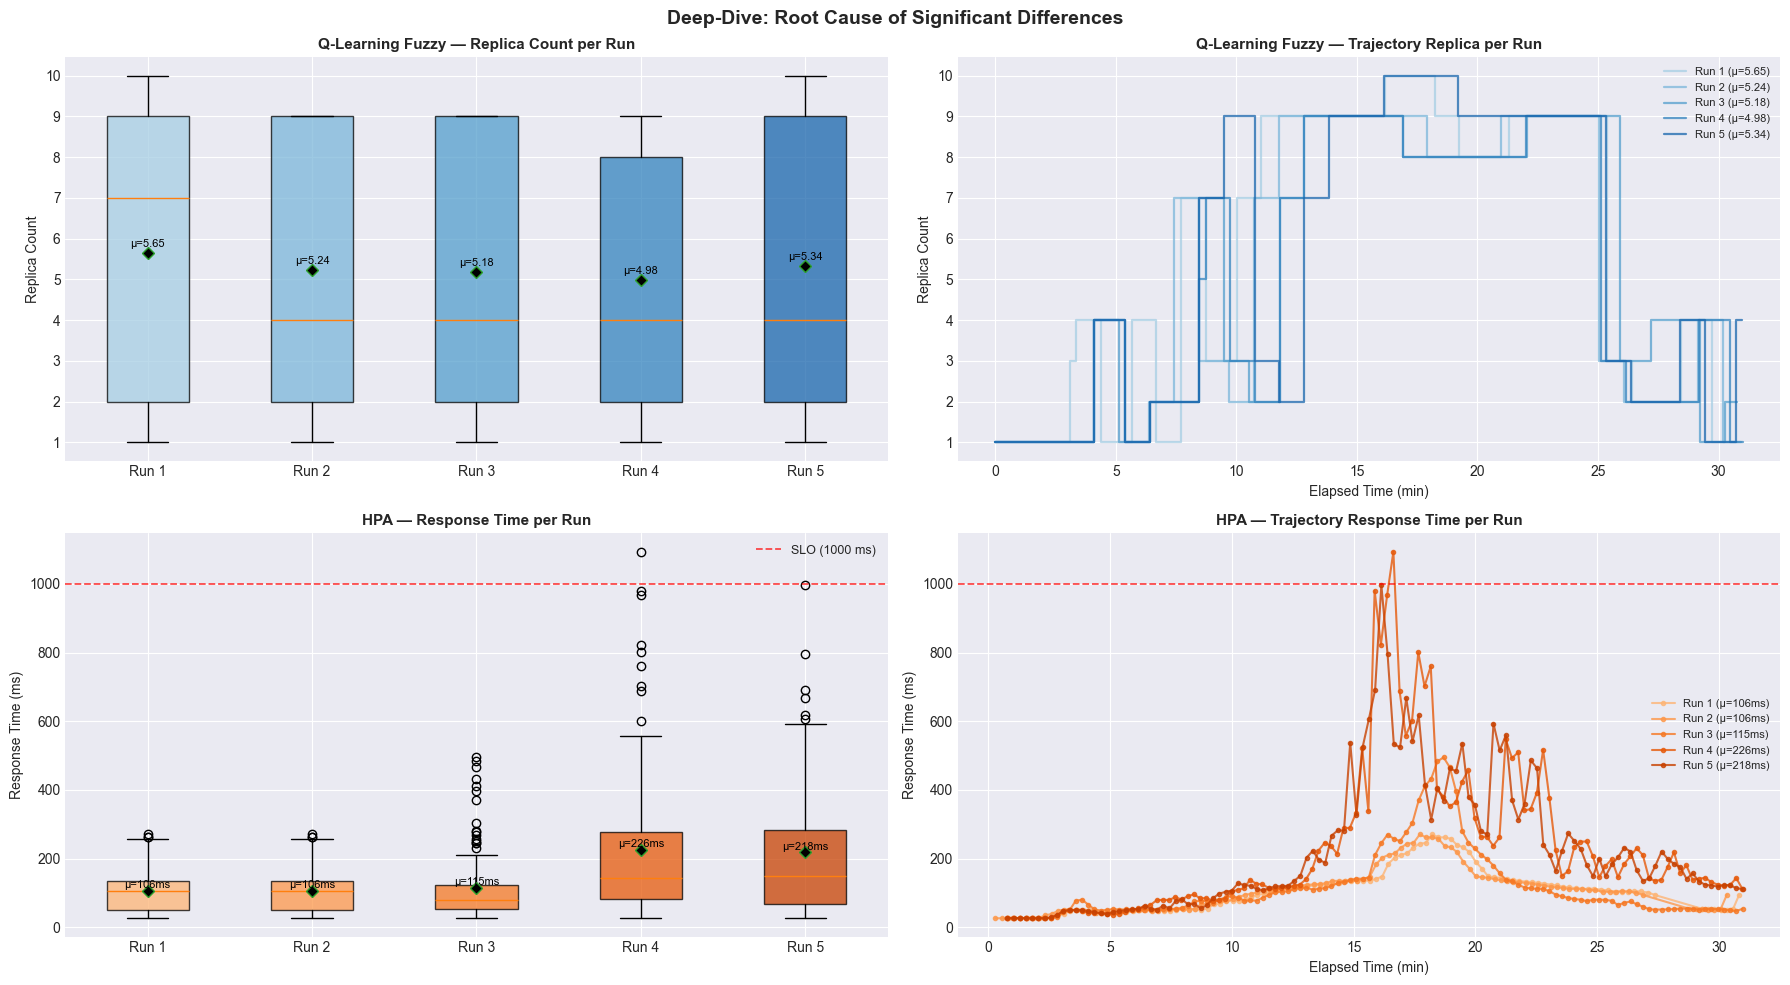


─── Post-hoc: Mann-Whitney U (Bonferroni-corrected) ───────────────

Q-Learning Fuzzy — Replica  (n_comparisons=10, α_adj=0.0050)
  Pair             U-stat       p-raw       p-adj  Significant?
  Run1 vs Run2      8008.5      0.2408      1.0000        ✓ sama
  Run1 vs Run3      8128.0      0.1306      1.0000        ✓ sama
  Run1 vs Run4      8397.0      0.0591      0.5912        ✓ sama
  Run1 vs Run5      7543.5      0.7621      1.0000        ✓ sama
  Run2 vs Run3      7581.5      0.7095      1.0000        ✓ sama
  Run2 vs Run4      7863.0      0.4367      1.0000        ✓ sama
  Run2 vs Run5      7015.5      0.4287      1.0000        ✓ sama
  Run3 vs Run4      7614.5      0.6655      1.0000        ✓ sama
  Run3 vs Run5      6820.5      0.2976      1.0000        ✓ sama
  Run4 vs Run5      6700.5      0.1712      1.0000        ✓ sama

HPA — Response Time  (n_comparisons=10, α_adj=0.0050)
  Pair             U-stat       p-raw       p-adj  Significant?
  Run1 vs Run2      6162.5      0.99

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Deep-Dive: Root Cause of Significant Differences', fontsize=14, fontweight='bold')

# ── [A] Q-Learning Fuzzy: Replica Count per run (boxplot) ────────
ax = axes[0, 0]
qf_dfs = ALL_DATA['Q-Learning Fuzzy']
qf_colors = METHOD_COLORS['Q-Learning Fuzzy']
qf_rep_groups = [df['replica_state'].values for df in qf_dfs]
bp = ax.boxplot(qf_rep_groups, labels=[f'Run {i+1}' for i in range(len(qf_dfs))],
                patch_artist=True, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 6})
for patch, color in zip(bp['boxes'], qf_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title('Q-Learning Fuzzy — Replica Count per Run', fontsize=11, fontweight='bold')
ax.set_ylabel('Replica Count')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Annotate mean per run
for i, g in enumerate(qf_rep_groups):
    ax.text(i + 1, np.mean(g) + 0.15, f'μ={np.mean(g):.2f}', ha='center', fontsize=8, color='black')

# ── [B] Q-Learning Fuzzy: Replica Count time-series overlay ──────
ax = axes[0, 1]
for i, df in enumerate(qf_dfs):
    ax.step(df['elapsed_min'], df['replica_state'], where='post',
            linewidth=1.6, alpha=0.75, color=qf_colors[i], label=f'Run {i+1} (μ={df["replica_state"].mean():.2f})')
ax.set_title('Q-Learning Fuzzy — Trajectory Replica per Run', fontsize=11, fontweight='bold')
ax.set_xlabel('Elapsed Time (min)')
ax.set_ylabel('Replica Count')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=8)

# ── [C] HPA: Response Time per run (boxplot) ─────────────────────
ax = axes[1, 0]
hpa_dfs = ALL_DATA['HPA']
hpa_colors = METHOD_COLORS['HPA']
hpa_rt_groups = []
for df in hpa_dfs:
    rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms'].values
    hpa_rt_groups.append(rt)

bp = ax.boxplot(hpa_rt_groups, labels=[f'Run {i+1}' for i in range(len(hpa_dfs))],
                patch_artist=True, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 6})
for patch, color in zip(bp['boxes'], hpa_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.3, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
ax.set_title('HPA — Response Time per Run', fontsize=11, fontweight='bold')
ax.set_ylabel('Response Time (ms)')
ax.legend(fontsize=9)

# Annotate mean per run
for i, g in enumerate(hpa_rt_groups):
    ax.text(i + 1, np.mean(g) + 8, f'μ={np.mean(g):.0f}ms', ha='center', fontsize=8, color='black')

# ── [D] HPA: Response Time time-series overlay ───────────────────
ax = axes[1, 1]
for i, df in enumerate(hpa_dfs):
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    mean_rt = df.loc[mask, 'response_time_ms'].mean()
    ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
            marker='o', markersize=3, linewidth=1.5,
            alpha=0.8, color=hpa_colors[i], label=f'Run {i+1} (μ={mean_rt:.0f}ms)')
ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.3, alpha=0.7)
ax.set_title('HPA — Trajectory Response Time per Run', fontsize=11, fontweight='bold')
ax.set_xlabel('Elapsed Time (min)')
ax.set_ylabel('Response Time (ms)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Pairwise post-hoc: Mann-Whitney U (bonferroni corrected) ──────
from itertools import combinations

print('\n─── Post-hoc: Mann-Whitney U (Bonferroni-corrected) ───────────────')
for label, groups, metric in [
    ('Q-Learning Fuzzy — Replica', qf_rep_groups, 'Replica'),
    ('HPA — Response Time',        hpa_rt_groups,  'RT'),
]:
    pairs = list(combinations(range(len(groups)), 2))
    n_comparisons = len(pairs)
    print(f'\n{label}  (n_comparisons={n_comparisons}, α_adj={ALPHA/n_comparisons:.4f})')
    print(f"  {'Pair':<12} {'U-stat':>10}  {'p-raw':>10}  {'p-adj':>10}  {'Significant?':>12}")
    for i, j in pairs:
        u, p_raw = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
        p_adj = min(p_raw * n_comparisons, 1.0)  # Bonferroni
        flag = '✗ berbeda' if p_adj <= ALPHA else '✓ sama'
        print(f"  Run{i+1} vs Run{j+1}  {u:>10.1f}  {p_raw:>10.4f}  {p_adj:>10.4f}  {flag:>12}")

### 12.2 Pencarian Kombinasi Run: Signifikan Antar Metode (Kruskal-Wallis)

Cari kombinasi 1 run dari tiap metode (QL × QF × HPA) yang menghasilkan perbedaan **signifikan antar metode** untuk **Replica Count** dan **Response Time** sekaligus.

Constraint: salah satu dari tiga run **harus** berasal dari:
- Q-Learning Run 2 (`test_Q-LEARNING_20260221_200210.csv`)
- Q-Learning Fuzzy Run 4 (`test_Q-LEARNING-FUZZY_20260221_211239.csv`)
- HPA Run 6 (`metrics_20260222_005111.csv`)

In [16]:
from scipy import stats
from itertools import product

ALPHA = 0.05

# Index run yang wajib ada (0-based, sesuai jumlah file yang dimuat)
# Q-Learning:       Run 2 → index 1  (5 file dimuat: Run 1,2,3,5,6)
# Q-Learning Fuzzy: Run 5 → index 3  (5 file dimuat: Run 1,2,3,5,6 — Run 4 tidak dimuat)
# HPA:              Run 6 → index 4  (5 file dimuat: Run 1,2,3,5,6)
REQUIRED = {
    'Q-Learning':       1,   # Run 2
    'Q-Learning Fuzzy': 3,   # Run 5 (Run 4 tidak dimuat)
    'HPA':              4,   # Run 6
}

def get_groups(ql_i, qf_i, hpa_i):
    """Kembalikan (rep_groups, rt_groups) untuk 3 run yang dipilih."""
    chosen = {
        'Q-Learning':       ALL_DATA['Q-Learning'][ql_i],
        'Q-Learning Fuzzy': ALL_DATA['Q-Learning Fuzzy'][qf_i],
        'HPA':              ALL_DATA['HPA'][hpa_i],
    }
    rep_groups, rt_groups = [], []
    for df in chosen.values():
        rep_groups.append(df['replica_state'].values)
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms'].values
        rt_groups.append(rt)
    return rep_groups, rt_groups

# Gunakan panjang aktual tiap dataset agar tidak IndexError
n_ql  = len(ALL_DATA['Q-Learning'])
n_qf  = len(ALL_DATA['Q-Learning Fuzzy'])
n_hpa = len(ALL_DATA['HPA'])

valid_combos = []

for ql_i, qf_i, hpa_i in product(range(n_ql), range(n_qf), range(n_hpa)):
    # Constraint: harus include salah satu run yang ditentukan
    has_required = (
        ql_i  == REQUIRED['Q-Learning']       or
        qf_i  == REQUIRED['Q-Learning Fuzzy'] or
        hpa_i == REQUIRED['HPA']
    )
    if not has_required:
        continue

    rep_groups, rt_groups = get_groups(ql_i, qf_i, hpa_i)

    try:
        _, p_rep = stats.kruskal(*rep_groups)
        _, p_rt  = stats.kruskal(*rt_groups)
    except Exception:
        continue

    if p_rep <= ALPHA and p_rt <= ALPHA:
        valid_combos.append({
            'QL Run':  ql_i + 1,
            'QF Run':  qf_i + 1,
            'HPA Run': hpa_i + 1,
            'p Replica': round(p_rep, 6),
            'p RT':      round(p_rt,  6),
            'min_p':     min(p_rep, p_rt),
        })

combo_df = pd.DataFrame(valid_combos).sort_values('min_p').reset_index(drop=True)
total_combos = n_ql * n_qf * n_hpa
print(f'Total valid combinations (both significant + constraint): {len(combo_df)} dari {total_combos}\n')
print(combo_df.drop(columns='min_p').to_string(index=False))

# ── Tandai kombinasi yang include SEMUA 3 file yang ditentukan ────
all_required = combo_df[
    (combo_df['QL Run']  == REQUIRED['Q-Learning'] + 1) &
    (combo_df['QF Run']  == REQUIRED['Q-Learning Fuzzy'] + 1) &
    (combo_df['HPA Run'] == REQUIRED['HPA'] + 1)
]
if not all_required.empty:
    print('\n★ Kombinasi yang menggunakan SEMUA 3 file yang ditentukan:')
    print(all_required.drop(columns='min_p').to_string(index=False))

# ── Rekomendasikan kombinasi terbaik (p terkecil = paling signifikan) ──
if not combo_df.empty:
    best = combo_df.iloc[0]
    print(f'\n✓ Best combination recommendation:')
    print(f'  Q-Learning       → Run {int(best["QL Run"])}')
    print(f'  Q-Learning Fuzzy → Run {int(best["QF Run"])}')
    print(f'  HPA              → Run {int(best["HPA Run"])}')
    print(f'  p Replica = {best["p Replica"]}  |  p RT = {best["p RT"]}')

Total valid combinations (both significant + constraint): 61 dari 125

 QL Run  QF Run  HPA Run  p Replica  p RT
      2       4        2       0.00  0.00
      5       4        2       0.00  0.00
      3       4        2       0.00  0.00
      1       4        2       0.00  0.00
      4       4        2       0.00  0.00
      2       2        2       0.00  0.00
      2       3        2       0.00  0.00
      2       4        1       0.00  0.00
      5       4        1       0.00  0.00
      2       4        5       0.00  0.00
      5       4        5       0.00  0.00
      4       4        1       0.00  0.00
      1       4        1       0.00  0.00
      3       4        1       0.00  0.00
      3       4        5       0.00  0.00
      1       4        5       0.00  0.00
      4       4        5       0.00  0.00
      2       2        1       0.00  0.00
      5       2        5       0.00  0.00
      2       2        5       0.00  0.00
      2       5        2       0.00  0.00
     

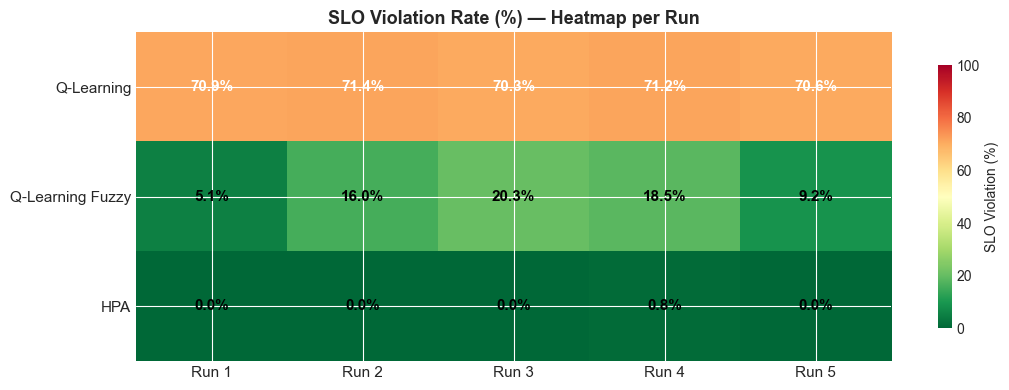

In [17]:
N_RUNS = 5

violation_matrix = np.full((len(methods), N_RUNS), np.nan)
for row, method in enumerate(methods):
    for col, df in enumerate(ALL_DATA[method]):
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
        if len(rt) > 0:
            violation_matrix[row, col] = (rt > SLO_THRESHOLD).sum() / len(rt) * 100

fig, ax = plt.subplots(figsize=(11, 4))

im = ax.imshow(violation_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='SLO Violation (%)', shrink=0.8)

ax.set_xticks(range(N_RUNS))
ax.set_xticklabels([f'Run {i+1}' for i in range(N_RUNS)], fontsize=11)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=11)
ax.set_title('SLO Violation Rate (%) — Heatmap per Run', fontsize=13, fontweight='bold')

# Annotate values
for row in range(len(methods)):
    for col in range(N_RUNS):
        val = violation_matrix[row, col]
        if not np.isnan(val):
            text_color = 'white' if val > 50 else 'black'
            ax.text(col, row, f'{val:.1f}%', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)

plt.tight_layout()
plt.show()

## 13. Mean Response Time (30 menit)

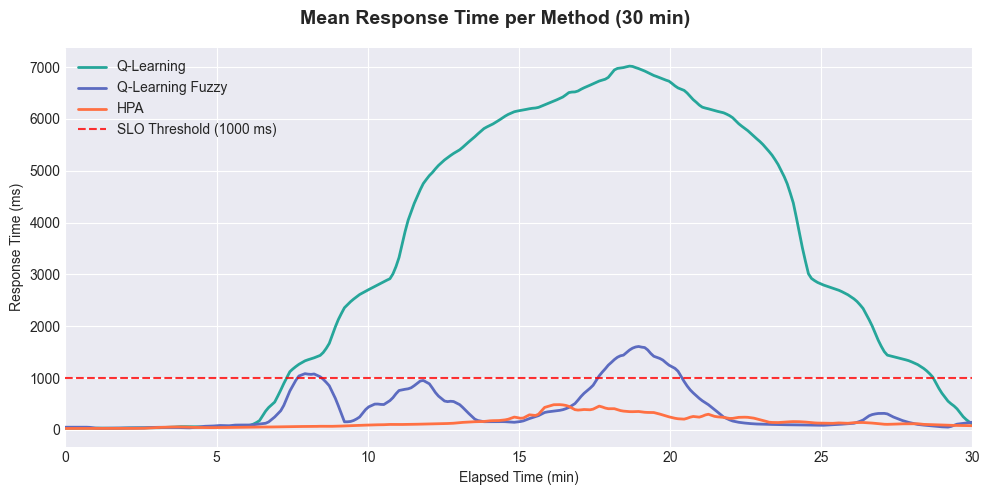

In [18]:
T_MAX = 30.0
T_POINTS = 300
t_grid = np.linspace(0, T_MAX, T_POINTS)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Mean Response Time per Method (30 min)', fontsize=14, fontweight='bold')

for method in methods:
    dfs = ALL_DATA[method]
    color = METHOD_BASE_COLOR[method]
    interp_list = []
    for df in dfs:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        d = df[mask]
        if len(d) > 0:
            interp_list.append(np.interp(t_grid, d['elapsed_min'].values, d['response_time_ms'].values))
    if interp_list:
        mean_rt = np.array(interp_list).mean(axis=0)
        ax.plot(t_grid, mean_rt, linewidth=2, color=color, label=method)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (min)')
ax.set_ylabel('Response Time (ms)')
ax.set_xlim(0, T_MAX)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 13.1 P90 & P95 Response Time per Method (30 min)

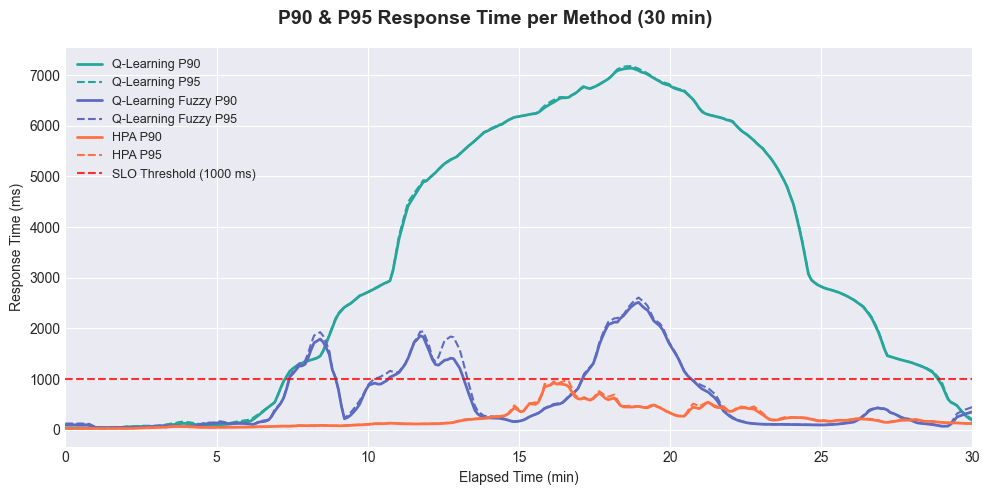

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('P90 & P95 Response Time per Method (30 min)', fontsize=14, fontweight='bold')

for method in methods:
    dfs = ALL_DATA[method]
    color = METHOD_BASE_COLOR[method]
    interp_list = []
    for df in dfs:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        d = df[mask]
        if len(d) > 0:
            interp_list.append(np.interp(t_grid, d['elapsed_min'].values, d['response_time_ms'].values))
    if interp_list:
        mat = np.array(interp_list)
        p90 = np.percentile(mat, 90, axis=0)
        p95 = np.percentile(mat, 95, axis=0)
        ax.plot(t_grid, p90, linewidth=2,   color=color, linestyle='-',  label=f'{method} P90')
        ax.plot(t_grid, p95, linewidth=1.5, color=color, linestyle='--', label=f'{method} P95')

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (min)')
ax.set_ylabel('Response Time (ms)')
ax.set_xlim(0, T_MAX)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## 14. Mean SLO Violation Rate — Perbandingan Metode (Bar Chart)

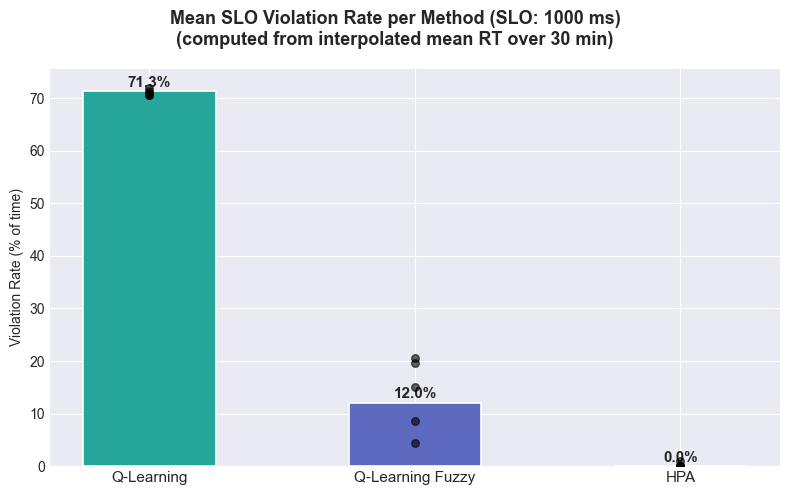

SLO Violation Rate from mean RT:
  Q-Learning           71.33%
  Q-Learning Fuzzy     12.00%
  HPA                  0.00%


In [20]:
# SLO violation dihitung dari mean RT per method (interpolated over t_grid)
# Violation = % time points where mean_rt > SLO_THRESHOLD
viol_means   = {}
viol_per_run = {}

for method in methods:
    dfs = ALL_DATA[method]
    interp_list = []
    for df in dfs:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        d = df[mask]
        if len(d) > 0:
            interp_list.append(np.interp(t_grid, d['elapsed_min'].values, d['response_time_ms'].values))

    if interp_list:
        mat = np.array(interp_list)           # (n_runs, T_POINTS)
        mean_rt = mat.mean(axis=0)            # mean across runs at each time point
        viol_rate = (mean_rt > SLO_THRESHOLD).mean() * 100
        # Per-run violation rate for scatter dots
        run_rates = [(row > SLO_THRESHOLD).mean() * 100 for row in mat]
    else:
        viol_rate = 0.0
        run_rates = []

    viol_means[method]   = viol_rate
    viol_per_run[method] = run_rates

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(f'Mean SLO Violation Rate per Method (SLO: {SLO_THRESHOLD} ms)\n'
             '(computed from interpolated mean RT over 30 min)',
             fontsize=13, fontweight='bold')

bar_colors = [METHOD_BASE_COLOR[m] for m in methods]
bars = ax.bar(methods, [viol_means[m] for m in methods],
              color=bar_colors, width=0.5, edgecolor='white', linewidth=1.2)

for bar, method in zip(bars, methods):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

for j, method in enumerate(methods):
    for rate in viol_per_run[method]:
        ax.scatter(j, rate, color='black', s=30, zorder=5, alpha=0.6)

ax.set_ylabel('Violation Rate (% of time)')
ax.set_ylim(bottom=0)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.show()

print('SLO Violation Rate from mean RT:')
for m in methods:
    print(f'  {m:<20} {viol_means[m]:.2f}%')

## 14.1 Mean SLO Violation Rate — Per Data Point (Averaged across Runs)

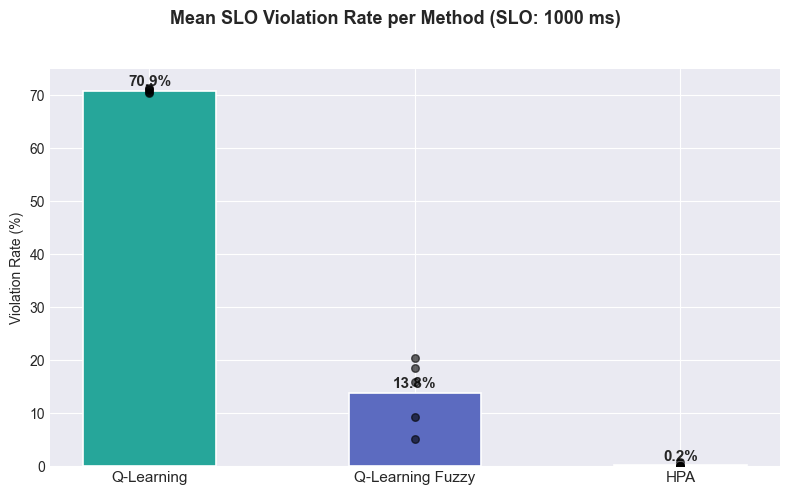

SLO Violation Rate (per data point):
  Q-Learning           mean=70.90%  per run: [70.9%, 71.4%, 70.3%, 71.2%, 70.6%]
  Q-Learning Fuzzy     mean=13.82%  per run: [5.1%, 16.0%, 20.3%, 18.5%, 9.2%]
  HPA                  mean=0.17%  per run: [0.0%, 0.0%, 0.0%, 0.8%, 0.0%]


In [21]:
# Hitung SLO violation per data point per run, lalu rata-rata antar run
viol_means_dp   = {}
viol_per_run_dp = {}

for method in methods:
    rates = []
    for df in ALL_DATA[method]:
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
        if len(rt) > 0:
            rates.append((rt > SLO_THRESHOLD).mean() * 100)
    viol_per_run_dp[method] = rates
    viol_means_dp[method]   = np.mean(rates)

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(f'Mean SLO Violation Rate per Method (SLO: {SLO_THRESHOLD} ms)\n',
             fontsize=13, fontweight='bold')

bar_colors = [METHOD_BASE_COLOR[m] for m in methods]
bars = ax.bar(methods, [viol_means_dp[m] for m in methods],
              color=bar_colors, width=0.5, edgecolor='white', linewidth=1.2)

for bar, method in zip(bars, methods):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

for j, method in enumerate(methods):
    for rate in viol_per_run_dp[method]:
        ax.scatter(j, rate, color='black', s=30, zorder=5, alpha=0.6)

ax.set_ylabel('Violation Rate (%)')
ax.set_ylim(bottom=0)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.show()

print('SLO Violation Rate (per data point):')
for m in methods:
    runs_str = ', '.join(f'{r:.1f}%' for r in viol_per_run_dp[m])
    print(f'  {m:<20} mean={viol_means_dp[m]:.2f}%  per run: [{runs_str}]')

## 15. Mean Replica Count (30 menit)

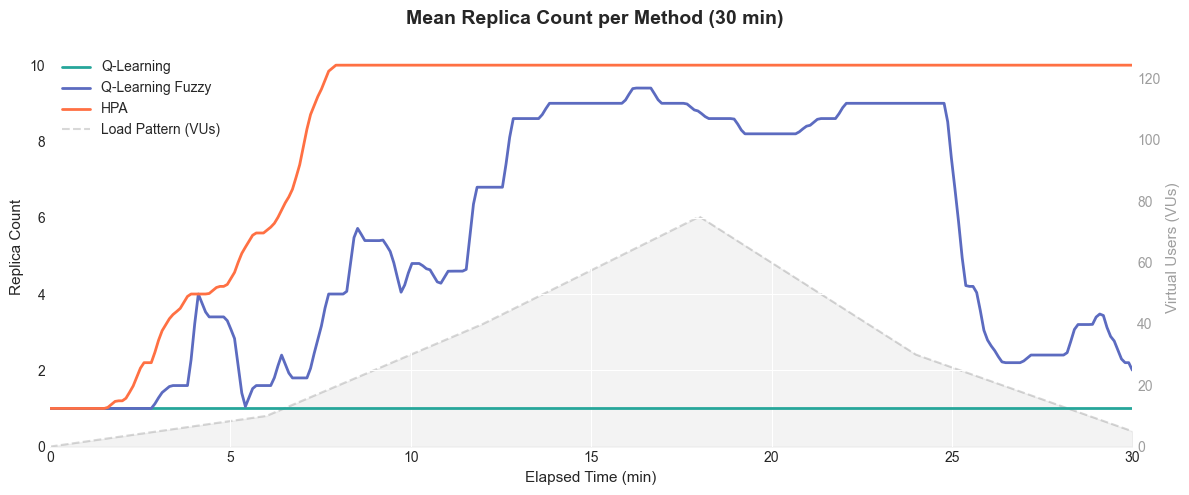

In [22]:
# k6 ramping-vus stages
k6_stages = [
    {"duration_min": 6, "target": 10},
    {"duration_min": 6, "target": 40},
    {"duration_min": 6, "target": 75},
    {"duration_min": 6, "target": 30},
    {"duration_min": 6, "target": 5},
]
k6_times_min = [0]
k6_vus = [0]
_t = 0
for stage in k6_stages:
    _t += stage["duration_min"]
    k6_times_min.append(_t)
    k6_vus.append(stage["target"])

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle('Mean Replica Count per Method (30 min)', fontsize=14, fontweight='bold')

# Background: Load pattern (VUs) — secondary y-axis
ax2 = ax1.twinx()
ax2.fill_between(k6_times_min, k6_vus, alpha=0.12, color='#9E9E9E')
ax2.plot(k6_times_min, k6_vus, linewidth=1.5, color='#9E9E9E', alpha=0.4,
         linestyle='--', label='Load Pattern (VUs)')
ax2.set_ylabel('Virtual Users (VUs)', color='#9E9E9E', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#9E9E9E', labelsize=10)
ax2.set_ylim(0, 130)

# Foreground: Mean replica count per method
for method in methods:
    dfs = ALL_DATA[method]
    color = METHOD_BASE_COLOR[method]
    rep_list = [np.interp(t_grid, df['elapsed_min'].values, df['replica_state'].values) for df in dfs]
    mean_rep = np.array(rep_list).mean(axis=0)
    ax1.plot(t_grid, mean_rep, linewidth=2, color=color, label=method)

ax1.set_xlabel('Elapsed Time (min)', fontsize=11)
ax1.set_ylabel('Replica Count', fontsize=11)
ax1.set_xlim(0, T_MAX)
ax1.set_ylim(bottom=0)
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Ensure foreground on top
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# Combined legend — fixed position upper left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## 16. Mean CPU & Memory Usage (30 menit)

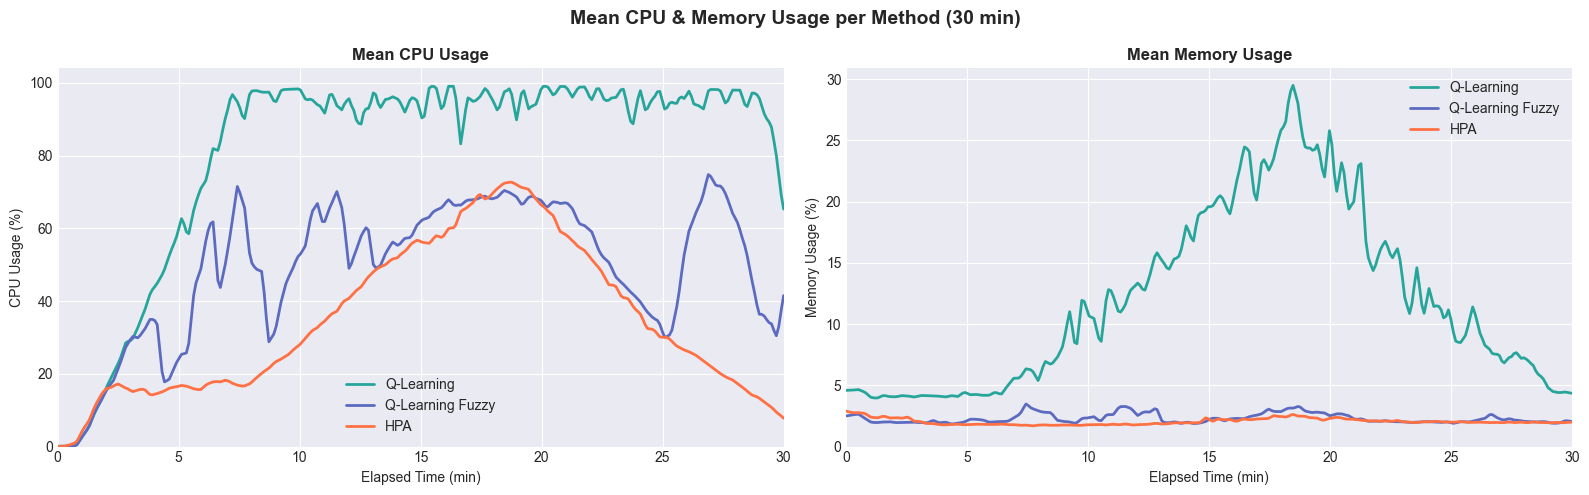

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Mean CPU & Memory Usage per Method (30 min)', fontsize=14, fontweight='bold')

ax_cpu, ax_mem = axes

for method in methods:
    dfs = ALL_DATA[method]
    color = METHOD_BASE_COLOR[method]

    cpu_list = [np.interp(t_grid, df['elapsed_min'].values, df['cpu_usage'].values) for df in dfs]
    mem_list = [np.interp(t_grid, df['elapsed_min'].values, df['memory_usage'].values) for df in dfs]

    mean_cpu = np.array(cpu_list).mean(axis=0)
    mean_mem = np.array(mem_list).mean(axis=0)

    ax_cpu.plot(t_grid, mean_cpu, linewidth=2, color=color, label=method)
    ax_mem.plot(t_grid, mean_mem, linewidth=2, color=color, label=method)

ax_cpu.set_title('Mean CPU Usage', fontsize=12, fontweight='bold')
ax_cpu.set_xlabel('Elapsed Time (min)')
ax_cpu.set_ylabel('CPU Usage (%)')
ax_cpu.set_xlim(0, T_MAX)
ax_cpu.set_ylim(bottom=0)
ax_cpu.legend(fontsize=10)

ax_mem.set_title('Mean Memory Usage', fontsize=12, fontweight='bold')
ax_mem.set_xlabel('Elapsed Time (min)')
ax_mem.set_ylabel('Memory Usage (%)')
ax_mem.set_xlim(0, T_MAX)
ax_mem.set_ylim(bottom=0)
ax_mem.legend(fontsize=10)

plt.tight_layout()
plt.show()

Q Learning Fuzzy (ms)
P90 : 248.66,364.19,325.82,389,306
P95 : 432.41,914.2,898.58,924.01,533.4

Q Learning (s)
P90 : 4.74,4.69,4.69,4.69,4.79
P95 : 7.29,7.29,7.29,7.2,7.28

HPA (ms)
P90 : 202.63,192.42,186.39,299.89,303.91
P95 : 268.14,256.05,279.9,580.66,574.35

In [24]:
import numpy as np

# Data dari k6 — Q-Learning dalam detik (s), dikonversi ke ms (* 1000)
k6_data = {
    'Q-Learning Fuzzy': {
        'P90': [248.66, 364.19, 325.82, 389.00, 306.00],
        'P95': [432.41, 914.20, 898.58, 924.01, 533.40],
    },
    'Q-Learning': {
        'P90': [v * 1000 for v in [4.74, 4.69, 4.69, 4.69, 4.79]],  # s → ms
        'P95': [v * 1000 for v in [7.29, 7.29, 7.29, 7.20, 7.28]],  # s → ms
    },
    'HPA': {
        'P90': [202.63, 192.42, 186.39, 299.89, 303.91],
        'P95': [268.14, 256.05, 279.90, 580.66, 574.35],
    },
}

print(f"{'Method':<20} {'P90 Mean (ms)':>15} {'P95 Mean (ms)':>15}")
print("=" * 52)
for method, stats in k6_data.items():
    p90_mean = np.mean(stats['P90'])
    p95_mean = np.mean(stats['P95'])
    print(f"{method:<20} {p90_mean:>15.2f} {p95_mean:>15.2f}")

Method                 P90 Mean (ms)   P95 Mean (ms)
Q-Learning Fuzzy              326.73          740.52
Q-Learning                   4720.00         7270.00
HPA                           237.05          391.82
